In [2]:
# ============================================================
# CELL 1: Imports, Environment Setup, and Reproducibility
# ============================================================

# Standard libraries
import os
import random
import warnings

# Reduce TensorFlow messages
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"
os.environ["PYTHONHASHSEED"] = "42"

# Data handling and plotting
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# TensorFlow / Keras
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense, BatchNormalization, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# Scikit-learn: preprocessing, feature selection, splitting, metrics
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_curve,
    auc
)

# Ignore non-critical warnings for a cleaner notebook
warnings.filterwarnings("ignore")

# ------------------------------------------------------------
# Reproducibility: use the same random seed on every run
# ------------------------------------------------------------
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)

# Make TensorFlow operations deterministic where supported
try:
    tf.config.experimental.enable_op_determinism()
except Exception:
    pass

print("Imports completed successfully.")
print("TensorFlow version:", tf.__version__)
print("Random seed:", SEED)
print("\nProject architecture to be built:")
print("20 → 10 → 10 → 10 → 10 → 10 → 1")
print("Input features used: 20 (selected from the 30 WDBC clinical features)")

Imports completed successfully.
TensorFlow version: 2.20.0
Random seed: 42

Project architecture to be built:
20 → 10 → 10 → 10 → 10 → 10 → 1
Input features used: 20 (selected from the 30 WDBC clinical features)


In [3]:
# ============================================================
# CELL 2: Download and Load the WDBC Dataset from UCI
# ============================================================

# UCI WDBC data file URL
url = (
    "https://archive.ics.uci.edu/ml/machine-learning-databases/"
    "breast-cancer-wisconsin/wdbc.data"
)

# Meaningful names for the 30 clinical input variables
feature_names = [
    "mean_radius", "mean_texture", "mean_perimeter", "mean_area",
    "mean_smoothness", "mean_compactness", "mean_concavity",
    "mean_concave_points", "mean_symmetry", "mean_fractal_dimension",

    "radius_se", "texture_se", "perimeter_se", "area_se",
    "smoothness_se", "compactness_se", "concavity_se",
    "concave_points_se", "symmetry_se", "fractal_dimension_se",

    "worst_radius", "worst_texture", "worst_perimeter", "worst_area",
    "worst_smoothness", "worst_compactness", "worst_concavity",
    "worst_concave_points", "worst_symmetry", "worst_fractal_dimension"
]

# Full dataset column list:
# ID + diagnosis label + 30 numerical clinical features
column_names = ["ID", "Diagnosis"] + feature_names

# Load the CSV file (it has no header row)
df = pd.read_csv(url, header=None, names=column_names)

# Basic checks
print("Dataset downloaded and loaded successfully.")
print(f"Dataset shape: {df.shape}")
print(f"Number of patients: {df.shape[0]}")
print(f"Number of columns: {df.shape[1]}")
print(f"Number of clinical features: {len(feature_names)}")

print("\nFirst five records:")
display(df.head())

print("\nMissing values in the dataset:", df.isnull().sum().sum())

Dataset downloaded and loaded successfully.
Dataset shape: (569, 32)
Number of patients: 569
Number of columns: 32
Number of clinical features: 30

First five records:


,ID,Diagnosis,mean_radius,mean_texture,mean_perimeter,mean_area,mean_smoothness,mean_compactness,mean_concavity,mean_concave_points,...,worst_radius,worst_texture,worst_perimeter,worst_area,worst_smoothness,worst_compactness,worst_concavity,worst_concave_points,worst_symmetry,worst_fractal_dimension
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678



Missing values in the dataset: 0


Original diagnosis distribution:
Diagnosis
B    357
M    212
Name: count, dtype: int64

Diagnosis encoding used for the neural network:
Benign (B)    → 0
Malignant (M) → 1


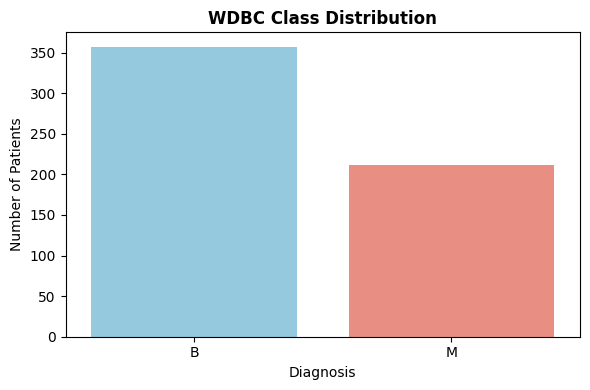


Prepared variables:
X_full shape: (569, 30)  → all 30 original clinical features
y shape:      (569,)       → binary diagnosis target

Encoded target distribution:
Diagnosis
Benign (0)       357
Malignant (1)    212
Name: count, dtype: int64


In [4]:
# ============================================================
# CELL 3: Explore Diagnosis Classes and Prepare X/y
# ============================================================

# Display original class distribution
class_counts = df["Diagnosis"].value_counts()

print("Original diagnosis distribution:")
print(class_counts)

print("\nDiagnosis encoding used for the neural network:")
print("Benign (B)    → 0")
print("Malignant (M) → 1")

# Plot class distribution
plt.figure(figsize=(6, 4))
sns.countplot(
    data=df,
    x="Diagnosis",
    order=["B", "M"],
    hue="Diagnosis",
    palette={"B": "skyblue", "M": "salmon"},
    legend=False
)

plt.title("WDBC Class Distribution", fontweight="bold")
plt.xlabel("Diagnosis")
plt.ylabel("Number of Patients")
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# Create input matrix with all 30 available clinical features.
# We will later select exactly 20 features using TRAINING DATA ONLY.
# ------------------------------------------------------------
X_full = df[feature_names].copy()

# Explicit target encoding:
# B (Benign) = 0, M (Malignant) = 1
y = df["Diagnosis"].map({"B": 0, "M": 1}).astype(int)

# Safety checks
assert X_full.shape == (569, 30), "Expected 569 rows and 30 source features."
assert set(y.unique()) == {0, 1}, "Target must contain only 0 and 1."

print("\nPrepared variables:")
print(f"X_full shape: {X_full.shape}  → all 30 original clinical features")
print(f"y shape:      {y.shape}       → binary diagnosis target")

print("\nEncoded target distribution:")
print(y.value_counts().sort_index().rename(index={0: 'Benign (0)', 1: 'Malignant (1)'}))

In [5]:

# ============================================================
# CELL 4: Stratified Train / Validation / Test Split
# ============================================================

# First split:
# 70% training data and 30% temporary data
X_train_full, X_temp, y_train, y_temp = train_test_split(
    X_full,
    y,
    test_size=0.30,
    random_state=SEED,
    stratify=y
)

# Second split:
# Split temporary 30% equally into 15% validation and 15% test
X_val_full, X_test_full, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=SEED,
    stratify=y_temp
)

# Print split sizes
print("Dataset split completed successfully.\n")

print(f"Training set:   {X_train_full.shape[0]} patients "
      f"({X_train_full.shape[0] / len(X_full) * 100:.1f}%)")

print(f"Validation set: {X_val_full.shape[0]} patients "
      f"({X_val_full.shape[0] / len(X_full) * 100:.1f}%)")

print(f"Test set:       {X_test_full.shape[0]} patients "
      f"({X_test_full.shape[0] / len(X_full) * 100:.1f}%)")

# Verify diagnosis balance in each set
split_distribution = pd.DataFrame({
    "Train": y_train.value_counts().sort_index(),
    "Validation": y_val.value_counts().sort_index(),
    "Test": y_test.value_counts().sort_index()
})

split_distribution.index = ["Benign (0)", "Malignant (1)"]

print("\nClass distribution after stratified splitting:")
display(split_distribution)

# Safety checks
assert len(X_train_full) + len(X_val_full) + len(X_test_full) == len(X_full)
assert X_train_full.shape[1] == 30
assert X_val_full.shape[1] == 30
assert X_test_full.shape[1] == 30

Dataset split completed successfully.

Training set:   398 patients (69.9%)
Validation set: 85 patients (14.9%)
Test set:       86 patients (15.1%)

Class distribution after stratified splitting:


,Train,Validation,Test
Benign (0),250,53,54
Malignant (1),148,32,32


In [6]:
# ============================================================
# CELL 5: Select the Best 20 Features Using Training Data Only
# ============================================================

# Select the 20 strongest features using ANOVA F-score.
# The selector is FIT only on training data to avoid data leakage.
feature_selector = SelectKBest(score_func=f_classif, k=20)

# Learn feature importance using training data only
feature_selector.fit(X_train_full, y_train)

# Get the names of the selected 20 features
selected_mask = feature_selector.get_support()
selected_feature_names = X_train_full.columns[selected_mask].tolist()

# Apply exactly the same selected features to all datasets
X_train_20 = X_train_full[selected_feature_names].copy()
X_val_20 = X_val_full[selected_feature_names].copy()
X_test_20 = X_test_full[selected_feature_names].copy()

# Create a table of all feature scores for documentation/reporting
feature_scores = pd.DataFrame({
    "Feature": X_train_full.columns,
    "ANOVA_F_Score": feature_selector.scores_,
    "p_value": feature_selector.pvalues_,
    "Selected_for_20_Input_Model": selected_mask
}).sort_values(by="ANOVA_F_Score", ascending=False)

print("Feature selection completed using training data only.")
print("\nSelected 20 features for the input layer:\n")

for number, feature in enumerate(selected_feature_names, start=1):
    print(f"{number:2d}. {feature}")

print("\nShapes after selecting exactly 20 features:")
print(f"X_train_20 shape: {X_train_20.shape}")
print(f"X_val_20 shape:   {X_val_20.shape}")
print(f"X_test_20 shape:  {X_test_20.shape}")

# Safety checks: The model must receive exactly 20 inputs.
assert X_train_20.shape[1] == 20
assert X_val_20.shape[1] == 20
assert X_test_20.shape[1] == 20

print("\nTop 20 features ranked by ANOVA F-score:")
display(feature_scores.head(20).reset_index(drop=True))

Feature selection completed using training data only.

Selected 20 features for the input layer:

 1. mean_radius
 2. mean_texture
 3. mean_perimeter
 4. mean_area
 5. mean_smoothness
 6. mean_compactness
 7. mean_concavity
 8. mean_concave_points
 9. radius_se
10. perimeter_se
11. area_se
12. worst_radius
13. worst_texture
14. worst_perimeter
15. worst_area
16. worst_smoothness
17. worst_compactness
18. worst_concavity
19. worst_concave_points
20. worst_symmetry

Shapes after selecting exactly 20 features:
X_train_20 shape: (398, 20)
X_val_20 shape:   (85, 20)
X_test_20 shape:  (86, 20)

Top 20 features ranked by ANOVA F-score:


,Feature,ANOVA_F_Score,p_value,Selected_for_20_Input_Model
0,worst_perimeter,619.823294,5.047178e-83,True
1,worst_concave_points,612.841093,1.981951e-82,True
2,worst_radius,595.042825,6.764170e-81,True
3,mean_concave_points,569.210242,1.274217e-78,True
4,worst_area,470.875421,2.304905e-69,True
5,mean_perimeter,467.003005,5.603431e-69,True
6,mean_radius,433.308866,1.515667e-65,True
7,mean_area,387.891499,1.085056e-60,True
8,mean_concavity,313.904115,3.843804e-52,True
9,worst_concavity,254.857117,1.197346e-44,True


In [7]:
# ============================================================
# CELL 6: Standardize the 20 Selected Input Features
# ============================================================

# Create the scaler
scaler = StandardScaler()

# Fit ONLY on the training set, then transform all three sets.
# This prevents validation/test information from leaking into training.
X_train_scaled = scaler.fit_transform(X_train_20)
X_val_scaled = scaler.transform(X_val_20)
X_test_scaled = scaler.transform(X_test_20)

# Convert scaled arrays back to DataFrames for readable feature names
X_train_scaled_df = pd.DataFrame(
    X_train_scaled,
    columns=selected_feature_names,
    index=X_train_20.index
)

X_val_scaled_df = pd.DataFrame(
    X_val_scaled,
    columns=selected_feature_names,
    index=X_val_20.index
)

X_test_scaled_df = pd.DataFrame(
    X_test_scaled,
    columns=selected_feature_names,
    index=X_test_20.index
)

print("Feature standardization completed successfully.\n")

print("Scaled data shapes:")
print(f"X_train_scaled: {X_train_scaled.shape}")
print(f"X_val_scaled:   {X_val_scaled.shape}")
print(f"X_test_scaled:  {X_test_scaled.shape}")

print("\nTraining-data scaling check:")
print(f"Overall training mean: {X_train_scaled.mean():.6f}  (approximately 0)")
print(f"Overall training std:  {X_train_scaled.std():.6f}  (approximately 1)")

print("\nFirst five scaled training examples:")
display(X_train_scaled_df.head())

# Final safety checks for the required input dimension
assert X_train_scaled.shape[1] == 20
assert X_val_scaled.shape[1] == 20
assert X_test_scaled.shape[1] == 20

Feature standardization completed successfully.

Scaled data shapes:
X_train_scaled: (398, 20)
X_val_scaled:   (85, 20)
X_test_scaled:  (86, 20)

Training-data scaling check:
Overall training mean: -0.000000  (approximately 0)
Overall training std:  1.000000  (approximately 1)

First five scaled training examples:


,mean_radius,mean_texture,mean_perimeter,mean_area,mean_smoothness,mean_compactness,mean_concavity,mean_concave_points,radius_se,perimeter_se,area_se,worst_radius,worst_texture,worst_perimeter,worst_area,worst_smoothness,worst_compactness,worst_concavity,worst_concave_points,worst_symmetry
78,1.705820,1.049745,2.121295,1.669337,2.276458,4.544295,3.539139,2.848393,1.886582,2.872750,1.749217,1.459510,0.949589,1.868176,1.306840,1.335383,2.313855,2.346427,2.049399,3.944281
330,0.536388,-0.909945,0.569095,0.390316,-0.065868,0.644945,0.393543,0.557002,-0.250414,-0.118574,-0.161492,0.508294,-0.645315,0.501917,0.330087,0.477013,1.242091,1.052574,1.255850,0.167978
378,-0.131456,-0.993336,-0.148848,-0.211543,-0.916169,-0.508574,-0.567530,-0.606645,-0.958073,-0.877833,-0.665315,-0.362451,-1.028485,-0.280415,-0.399387,-0.196219,0.368661,-0.080795,-0.140014,0.741988
213,0.928077,1.418055,0.925405,0.828546,0.329734,0.223748,0.983188,0.443947,0.441432,0.446896,0.419099,0.365921,0.351910,0.386082,0.243539,-0.330866,-0.464721,0.030311,-0.072253,-2.040715
89,0.144699,-0.972488,0.158315,-0.009697,1.205760,0.585041,0.137701,0.562858,0.376381,0.470250,0.056632,0.008957,-1.257732,0.059367,-0.140450,-0.187804,0.359126,-0.064176,0.376471,0.373873


In [8]:
# ============================================================
# CELL 7: Define the Baseline FFNN Architecture
# Required architecture: 20 → 10 → 10 → 10 → 10 → 10 → 1
# ============================================================

# Reset seed before model creation for reproducibility
tf.keras.utils.set_random_seed(SEED)

# Baseline Feedforward Neural Network
baseline_model = Sequential([

    # Input layer: exactly 20 selected clinical features
    Input(shape=(20,), name="Input_Layer_20_Features"),

    # Hidden Layer 1: 20 → 10
    Dense(10, activation="relu", name="Hidden_Layer_1"),

    # Hidden Layer 2: 10 → 10
    Dense(10, activation="relu", name="Hidden_Layer_2"),

    # Hidden Layer 3: 10 → 10
    Dense(10, activation="relu", name="Hidden_Layer_3"),

    # Hidden Layer 4: 10 → 10
    Dense(10, activation="relu", name="Hidden_Layer_4"),

    # Hidden Layer 5: 10 → 10
    Dense(10, activation="relu", name="Hidden_Layer_5"),

    # Output layer: binary classification probability of Malignant = 1
    Dense(1, activation="sigmoid", name="Output_Layer")
], name="Baseline_FFNN_20_Input")

# Display architecture
baseline_model.summary()

# Verify parameter count
total_params = baseline_model.count_params()

print(f"\nTotal trainable parameters reported by Keras: {total_params}")

expected_params = (
    (20 * 10 + 10) +  # Input → Hidden 1
    (10 * 10 + 10) +  # Hidden 1 → Hidden 2
    (10 * 10 + 10) +  # Hidden 2 → Hidden 3
    (10 * 10 + 10) +  # Hidden 3 → Hidden 4
    (10 * 10 + 10) +  # Hidden 4 → Hidden 5
    (10 * 1 + 1)      # Hidden 5 → Output
)

print(f"Expected manual parameter count: {expected_params}")

assert total_params == expected_params == 661, "Parameter count should be 661."
print("\n✓ Architecture verified: 20 → 10 → 10 → 10 → 10 → 10 → 1")
print("✓ Total trainable parameters verified: 661")

Model: "Baseline_FFNN_20_Input"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Hidden_Layer_1 (Dense)          │ (None, 10)             │           210 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Hidden_Layer_2 (Dense)          │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Hidden_Layer_3 (Dense)          │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Hidden_Layer_4 (Dense)          │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Hidden_Layer_5 (Dense)          │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Output_Layer (Dense)            │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 661 (2.58 KB)

 Trainable params: 661 (2.58 KB)

 Non-trainable params: 0 (0.00 B)


Total trainable parameters reported by Keras: 661
Expected manual parameter count: 661

✓ Architecture verified: 20 → 10 → 10 → 10 → 10 → 10 → 1
✓ Total trainable parameters verified: 661


In [9]:
# ============================================================
# CELL 8: Compile the Baseline FFNN
# ============================================================

# Compile the baseline model.
# Binary Cross-Entropy is appropriate because:
# 1. The target has two classes: 0 (Benign), 1 (Malignant)
# 2. The output layer has one Sigmoid neuron that returns P(Malignant)
# 3. BCE penalizes confident incorrect predictions strongly.

baseline_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

print("Baseline model compiled successfully.\n")
print("Optimizer: Adam")
print("Learning rate: 0.001")
print("Loss function: Binary Cross-Entropy")
print("Evaluation metric: Accuracy")

print("\nBinary Cross-Entropy formula:")
print("Loss = -[y·log(p) + (1-y)·log(1-p)]")
print("where y is the true class and p is the predicted probability of Malignant.")

Baseline model compiled successfully.

Optimizer: Adam
Learning rate: 0.001
Loss function: Binary Cross-Entropy
Evaluation metric: Accuracy

Binary Cross-Entropy formula:
Loss = -[y·log(p) + (1-y)·log(1-p)]
where y is the true class and p is the predicted probability of Malignant.


In [10]:
# ============================================================
# CELL 9: Train the Baseline FFNN (No Regularization)
# ============================================================

# Reset random seed before training for reproducibility
tf.keras.utils.set_random_seed(SEED)

# Train the baseline model for the full 200 epochs.
# No early stopping is used here intentionally:
# we want to observe possible overfitting in the baseline model.
baseline_history = baseline_model.fit(
    X_train_scaled,
    y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=200,
    batch_size=32,
    verbose=0
)

print("Baseline model training completed for 200 epochs.\n")

# Create a readable table of selected epochs
baseline_training_table = pd.DataFrame({
    "Epoch": np.arange(1, 201),
    "Train Loss": baseline_history.history["loss"],
    "Validation Loss": baseline_history.history["val_loss"],
    "Train Accuracy": baseline_history.history["accuracy"],
    "Validation Accuracy": baseline_history.history["val_accuracy"]
})

# Display training progress at selected epochs
selected_epochs = [1, 5, 10, 20, 50, 100, 150, 200]

print("Baseline training progress at selected epochs:")
display(
    baseline_training_table[
        baseline_training_table["Epoch"].isin(selected_epochs)
    ].round(4)
)

# Find the epoch with the minimum validation loss
best_baseline_epoch = int(
    np.argmin(baseline_history.history["val_loss"]) + 1
)

best_baseline_val_loss = float(
    np.min(baseline_history.history["val_loss"])
)

best_baseline_val_acc = float(
    baseline_history.history["val_accuracy"][best_baseline_epoch - 1]
)

print(f"Best baseline validation loss: {best_baseline_val_loss:.4f}")
print(f"Epoch with best validation loss: {best_baseline_epoch}")
print(f"Validation accuracy at that epoch: {best_baseline_val_acc:.4f}")

print("\nFinal epoch (Epoch 200):")
print(f"Final Training Loss:      {baseline_history.history['loss'][-1]:.4f}")
print(f"Final Validation Loss:    {baseline_history.history['val_loss'][-1]:.4f}")
print(f"Final Training Accuracy:  {baseline_history.history['accuracy'][-1]:.4f}")
print(f"Final Validation Accuracy:{baseline_history.history['val_accuracy'][-1]:.4f}")

Baseline model training completed for 200 epochs.

Baseline training progress at selected epochs:


,Epoch,Train Loss,Validation Loss,Train Accuracy,Validation Accuracy
0,1,0.6930,0.6763,0.6106,0.8000
4,5,0.4906,0.4476,0.9070,0.9294
9,10,0.1802,0.1504,0.9271,0.9647
19,20,0.0862,0.0870,0.9749,0.9647
49,50,0.0421,0.0770,0.9874,0.9765
99,100,0.0040,0.1529,1.0000,0.9765
149,150,0.0007,0.2199,1.0000,0.9765
199,200,0.0002,0.2580,1.0000,0.9765


Best baseline validation loss: 0.0760
Epoch with best validation loss: 41
Validation accuracy at that epoch: 0.9765

Final epoch (Epoch 200):
Final Training Loss:      0.0002
Final Validation Loss:    0.2580
Final Training Accuracy:  1.0000
Final Validation Accuracy:0.9765


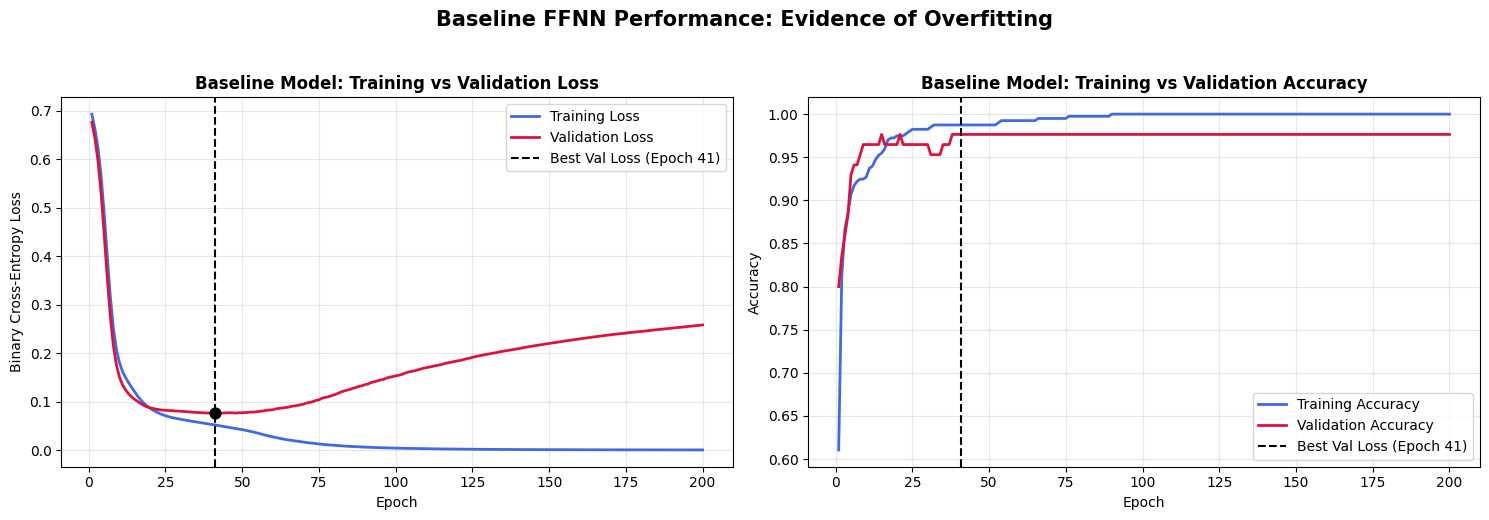

Baseline Overfitting Summary
---------------------------------------------
Best validation-loss epoch: 41
Best validation loss:       0.0760
Final train/validation loss gap: 0.2578
Final train/validation accuracy gap: 0.0235

Interpretation:
The baseline model overfits after its best validation-loss epoch. Training loss continues to decrease, while validation loss increases. Batch normalization, dropout, and early stopping will be added next.


In [11]:
# ============================================================
# CELL 10: Plot Baseline Training vs Validation Curves
# ============================================================

epochs_baseline = range(1, len(baseline_history.history["loss"]) + 1)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# ------------------------------------------------------------
# Plot 1: Training and Validation Loss
# ------------------------------------------------------------
axes[0].plot(
    epochs_baseline,
    baseline_history.history["loss"],
    label="Training Loss",
    color="royalblue",
    linewidth=2
)

axes[0].plot(
    epochs_baseline,
    baseline_history.history["val_loss"],
    label="Validation Loss",
    color="crimson",
    linewidth=2
)

# Mark best validation-loss epoch
axes[0].axvline(
    best_baseline_epoch,
    color="black",
    linestyle="--",
    linewidth=1.5,
    label=f"Best Val Loss (Epoch {best_baseline_epoch})"
)

axes[0].scatter(
    best_baseline_epoch,
    best_baseline_val_loss,
    color="black",
    s=60,
    zorder=5
)

axes[0].set_title("Baseline Model: Training vs Validation Loss", fontweight="bold")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Binary Cross-Entropy Loss")
axes[0].legend()
axes[0].grid(alpha=0.3)

# ------------------------------------------------------------
# Plot 2: Training and Validation Accuracy
# ------------------------------------------------------------
axes[1].plot(
    epochs_baseline,
    baseline_history.history["accuracy"],
    label="Training Accuracy",
    color="royalblue",
    linewidth=2
)

axes[1].plot(
    epochs_baseline,
    baseline_history.history["val_accuracy"],
    label="Validation Accuracy",
    color="crimson",
    linewidth=2
)

axes[1].axvline(
    best_baseline_epoch,
    color="black",
    linestyle="--",
    linewidth=1.5,
    label=f"Best Val Loss (Epoch {best_baseline_epoch})"
)

axes[1].set_title("Baseline Model: Training vs Validation Accuracy", fontweight="bold")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle(
    "Baseline FFNN Performance: Evidence of Overfitting",
    fontsize=15,
    fontweight="bold",
    y=1.03
)

plt.tight_layout()
plt.savefig("01_baseline_loss_accuracy.png", dpi=300, bbox_inches="tight")
plt.show()

# ------------------------------------------------------------
# Quantify the baseline overfitting gap
# ------------------------------------------------------------
final_train_loss = baseline_history.history["loss"][-1]
final_val_loss = baseline_history.history["val_loss"][-1]
loss_gap = final_val_loss - final_train_loss

final_train_acc = baseline_history.history["accuracy"][-1]
final_val_acc = baseline_history.history["val_accuracy"][-1]
accuracy_gap = final_train_acc - final_val_acc

print("Baseline Overfitting Summary")
print("-" * 45)
print(f"Best validation-loss epoch: {best_baseline_epoch}")
print(f"Best validation loss:       {best_baseline_val_loss:.4f}")
print(f"Final train/validation loss gap: {loss_gap:.4f}")
print(f"Final train/validation accuracy gap: {accuracy_gap:.4f}")

print("\nInterpretation:")
print(
    "The baseline model overfits after its best validation-loss epoch. "
    "Training loss continues to decrease, while validation loss increases. "
    "Batch normalization, dropout, and early stopping will be added next."
)

In [12]:
# ============================================================
# CELL 11: Define Regularized FFNN
# Architecture: 20 → 10 → 10 → 10 → 10 → 10 → 1
# Regularization: BatchNorm + Dropout(p=0.2)
# ============================================================

# Reset random seed before creating the regularized model
tf.keras.utils.set_random_seed(SEED)

reg_model = Sequential([

    # Input layer: exactly 20 selected WDBC clinical features
    Input(shape=(20,), name="Input_Layer_20_Features"),

    # Hidden Layer 1: 20 → 10
    Dense(10, name="Hidden_Layer_1"),
    BatchNormalization(name="BatchNorm_1"),
    keras.layers.Activation("relu", name="ReLU_1"),
    Dropout(0.2, name="Dropout_1"),

    # Hidden Layer 2: 10 → 10
    Dense(10, name="Hidden_Layer_2"),
    BatchNormalization(name="BatchNorm_2"),
    keras.layers.Activation("relu", name="ReLU_2"),
    Dropout(0.2, name="Dropout_2"),

    # Hidden Layer 3: 10 → 10
    Dense(10, name="Hidden_Layer_3"),
    BatchNormalization(name="BatchNorm_3"),
    keras.layers.Activation("relu", name="ReLU_3"),
    Dropout(0.2, name="Dropout_3"),

    # Hidden Layer 4: 10 → 10
    Dense(10, name="Hidden_Layer_4"),
    BatchNormalization(name="BatchNorm_4"),
    keras.layers.Activation("relu", name="ReLU_4"),
    Dropout(0.2, name="Dropout_4"),

    # Hidden Layer 5: 10 → 10
    Dense(10, name="Hidden_Layer_5"),
    BatchNormalization(name="BatchNorm_5"),
    keras.layers.Activation("relu", name="ReLU_5"),
    Dropout(0.2, name="Dropout_5"),

    # Output layer: probability that the case is Malignant (class 1)
    Dense(1, activation="sigmoid", name="Output_Layer")

], name="Regularized_FFNN_20_Input")

# Display regularized architecture and parameters
reg_model.summary()

# Parameter verification:
# Baseline Dense parameters = 661
# Each BatchNorm with 10 units adds:
# 20 trainable (gamma and beta) + 20 non-trainable (moving mean/variance)
# Five BatchNorm layers therefore add 200 total parameters.
print("\nRegularized-model parameter explanation:")
print("Baseline dense-layer parameters: 661")
print("Five BatchNorm layers add: 5 × 40 = 200 total parameters")
print("Expected total parameters: 861")
print(f"Keras reported total parameters: {reg_model.count_params()}")

assert reg_model.count_params() == 861, "Expected 861 total parameters."
print("\n✓ Regularized FFNN created successfully.")
print("✓ Batch Normalization added after each hidden linear layer.")
print("✓ Dropout(p=0.2) added after each hidden activation.")

Model: "Regularized_FFNN_20_Input"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Hidden_Layer_1 (Dense)          │ (None, 10)             │           210 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ BatchNorm_1                     │ (None, 10)             │            40 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ ReLU_1 (Activation)             │ (None, 10)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dropout_1 (Dropout)             │ (None, 10)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Hidden_Layer_2 (Dense)          │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ BatchNorm_2                     │ (None, 10)             │            40 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ ReLU_2 (Activation)             │ (None, 10)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dropout_2 (Dropout)             │ (None, 10)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Hidden_Layer_3 (Dense)          │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ BatchNorm_3                     │ (None, 10)             │            40 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ ReLU_3 (Activation)             │ (None, 10)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dropout_3 (Dropout)             │ (None, 10)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Hidden_Layer_4 (Dense)          │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ BatchNorm_4                     │ (None, 10)             │            40 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ ReLU_4 (Activation)             │ (None, 10)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dropout_4 (Dropout)             │ (None, 10)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Hidden_Layer_5 (Dense)          │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ BatchNorm_5                     │ (None, 10)             │            40 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ ReLU_5 (Activation)             │ (None, 10)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dropout_5 (Dropout)             │ (None, 10)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Output_Layer (Dense)            │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 861 (3.36 KB)

 Trainable params: 761 (2.97 KB)

 Non-trainable params: 100 (400.00 B)


Regularized-model parameter explanation:
Baseline dense-layer parameters: 661
Five BatchNorm layers add: 5 × 40 = 200 total parameters
Expected total parameters: 861
Keras reported total parameters: 861

✓ Regularized FFNN created successfully.
✓ Batch Normalization added after each hidden linear layer.
✓ Dropout(p=0.2) added after each hidden activation.


In [13]:
# ============================================================
# CELL 12: Compile Regularized Model + Define Early Stopping
# ============================================================

# Compile the regularized model using Adam and BCE.
reg_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

# Early stopping monitors validation loss.
# Training stops if val_loss does not improve for 10 consecutive epochs.
# restore_best_weights=True discards the final overfitted weights
# and restores the weights from the epoch with the lowest val_loss.
early_stopping_callback = EarlyStopping(
    monitor="val_loss",
    patience=10,
    min_delta=0.0001,
    restore_best_weights=True,
    verbose=1
)

print("Regularized model compiled successfully.\n")
print("Optimizer: Adam (learning rate = 0.001)")
print("Loss function: Binary Cross-Entropy")
print("Metric: Accuracy")

print("\nEarly Stopping configuration:")
print("Monitor: val_loss")
print("Patience: 10 epochs")
print("Minimum improvement (min_delta): 0.0001")
print("Restore best weights: True")

print("\nMeaning:")
print(
    "If validation loss does not decrease for 10 consecutive epochs, "
    "training will stop and the best validation-loss weights will be restored."
)

Regularized model compiled successfully.

Optimizer: Adam (learning rate = 0.001)
Loss function: Binary Cross-Entropy
Metric: Accuracy

Early Stopping configuration:
Monitor: val_loss
Patience: 10 epochs
Minimum improvement (min_delta): 0.0001
Restore best weights: True

Meaning:
If validation loss does not decrease for 10 consecutive epochs, training will stop and the best validation-loss weights will be restored.


In [14]:
# ============================================================
# CELL 13: Train Regularized FFNN with Early Stopping
# ============================================================

# Train for up to 300 epochs.
# Early stopping will stop training earlier if validation loss
# does not improve for 10 consecutive epochs.
reg_history = reg_model.fit(
    X_train_scaled,
    y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=300,
    batch_size=32,
    callbacks=[early_stopping_callback],
    verbose=0
)

# Number of epochs actually completed before early stopping
reg_epochs_completed = len(reg_history.history["loss"])

# Locate the epoch with the smallest validation loss
best_reg_epoch = int(np.argmin(reg_history.history["val_loss"]) + 1)
best_reg_val_loss = float(np.min(reg_history.history["val_loss"]))
best_reg_val_acc = float(
    reg_history.history["val_accuracy"][best_reg_epoch - 1]
)

print("Regularized-model training completed.\n")
print(f"Maximum permitted epochs: {300}")
print(f"Epochs actually completed: {reg_epochs_completed}")
print(f"Best validation-loss epoch: {best_reg_epoch}")
print(f"Best validation loss: {best_reg_val_loss:.4f}")
print(f"Validation accuracy at best-loss epoch: {best_reg_val_acc:.4f}")

# Table for reporting progress at selected epochs.
epochs_to_show = sorted(set(
    [1, 5, 10, 20, 50, 100, best_reg_epoch, reg_epochs_completed]
))

reg_training_table = pd.DataFrame({
    "Epoch": np.arange(1, reg_epochs_completed + 1),
    "Train Loss": reg_history.history["loss"],
    "Validation Loss": reg_history.history["val_loss"],
    "Train Accuracy": reg_history.history["accuracy"],
    "Validation Accuracy": reg_history.history["val_accuracy"]
})

print("\nRegularized-model training progress at selected epochs:")
display(
    reg_training_table[
        reg_training_table["Epoch"].isin(epochs_to_show)
    ].round(4)
)

print("\nFinal recorded epoch before stopping:")
print(f"Training Loss:      {reg_history.history['loss'][-1]:.4f}")
print(f"Validation Loss:    {reg_history.history['val_loss'][-1]:.4f}")
print(f"Training Accuracy:  {reg_history.history['accuracy'][-1]:.4f}")
print(f"Validation Accuracy:{reg_history.history['val_accuracy'][-1]:.4f}")

print("\nNote:")
print(
    "Keras has restored the best model weights based on validation loss "
    "because restore_best_weights=True."
)

Epoch 139: early stopping
Restoring model weights from the end of the best epoch: 129.
Regularized-model training completed.

Maximum permitted epochs: 300
Epochs actually completed: 139
Best validation-loss epoch: 129
Best validation loss: 0.1053
Validation accuracy at best-loss epoch: 0.9765

Regularized-model training progress at selected epochs:


,Epoch,Train Loss,Validation Loss,Train Accuracy,Validation Accuracy
0,1,0.9418,0.7041,0.3819,0.5059
4,5,0.7333,0.6378,0.4874,0.9294
9,10,0.5908,0.5297,0.6658,0.9294
19,20,0.4290,0.3687,0.8492,0.9176
49,50,0.3047,0.1870,0.8945,0.9294
99,100,0.1970,0.1157,0.9347,0.9647
128,129,0.1740,0.1053,0.9472,0.9765
138,139,0.1846,0.1083,0.9347,0.9647



Final recorded epoch before stopping:
Training Loss:      0.1846
Validation Loss:    0.1083
Training Accuracy:  0.9347
Validation Accuracy:0.9647

Note:
Keras has restored the best model weights based on validation loss because restore_best_weights=True.


Regularized Model Performance After Restoring Best Weights
----------------------------------------------------------
Restored training loss:       0.0779
Restored training accuracy:   0.9849
Restored validation loss:     0.1053
Restored validation accuracy: 0.9765


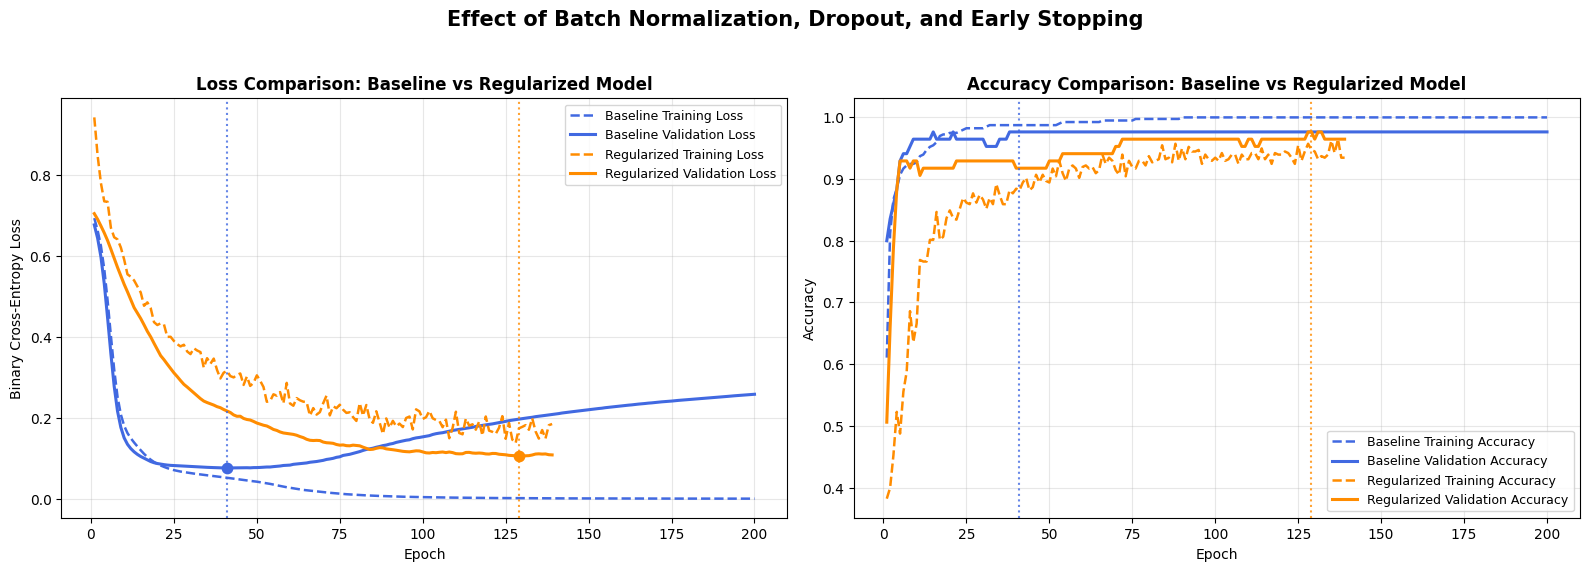


Baseline vs Regularized Model Summary


,Model,Selected Epoch,Best Validation Loss,Validation Accuracy
0,Baseline (best validation epoch),41,0.0760,0.9765
1,Regularized (restored best weights),129,0.1053,0.9765



Interpretation:
The baseline model reaches near-perfect training accuracy and then overfits, as indicated by increasing validation loss. The regularized model trains more gradually because Dropout is active during training. Early stopping prevents unnecessary training after validation loss stops improving.


In [15]:
# ============================================================
# CELL 14: Compare Baseline vs Regularized Model Curves
# ============================================================

# ------------------------------------------------------------
# Evaluate reg_model AFTER EarlyStopping restored its best weights.
# Note: model.evaluate() runs with Dropout disabled, which is
# correct for evaluation/inference.
# ------------------------------------------------------------
reg_train_loss_restored, reg_train_acc_restored = reg_model.evaluate(
    X_train_scaled, y_train, verbose=0
)

reg_val_loss_restored, reg_val_acc_restored = reg_model.evaluate(
    X_val_scaled, y_val, verbose=0
)

print("Regularized Model Performance After Restoring Best Weights")
print("-" * 58)
print(f"Restored training loss:       {reg_train_loss_restored:.4f}")
print(f"Restored training accuracy:   {reg_train_acc_restored:.4f}")
print(f"Restored validation loss:     {reg_val_loss_restored:.4f}")
print(f"Restored validation accuracy: {reg_val_acc_restored:.4f}")

# ------------------------------------------------------------
# Create epoch ranges for both models
# ------------------------------------------------------------
epochs_baseline = range(1, len(baseline_history.history["loss"]) + 1)
epochs_reg = range(1, len(reg_history.history["loss"]) + 1)

# ------------------------------------------------------------
# Plot comparisons
# Dashed lines = training
# Solid lines = validation
# ------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(16, 5.5))

# ===== Loss Comparison =====
axes[0].plot(
    epochs_baseline,
    baseline_history.history["loss"],
    color="royalblue",
    linestyle="--",
    linewidth=1.8,
    label="Baseline Training Loss"
)

axes[0].plot(
    epochs_baseline,
    baseline_history.history["val_loss"],
    color="royalblue",
    linewidth=2.2,
    label="Baseline Validation Loss"
)

axes[0].plot(
    epochs_reg,
    reg_history.history["loss"],
    color="darkorange",
    linestyle="--",
    linewidth=1.8,
    label="Regularized Training Loss"
)

axes[0].plot(
    epochs_reg,
    reg_history.history["val_loss"],
    color="darkorange",
    linewidth=2.2,
    label="Regularized Validation Loss"
)

# Mark each model's best validation-loss epoch
axes[0].axvline(
    best_baseline_epoch,
    color="royalblue",
    linestyle=":",
    linewidth=1.5,
    alpha=0.8
)

axes[0].axvline(
    best_reg_epoch,
    color="darkorange",
    linestyle=":",
    linewidth=1.5,
    alpha=0.8
)

axes[0].scatter(
    best_baseline_epoch,
    best_baseline_val_loss,
    color="royalblue",
    s=55,
    zorder=5
)

axes[0].scatter(
    best_reg_epoch,
    best_reg_val_loss,
    color="darkorange",
    s=55,
    zorder=5
)

axes[0].set_title(
    "Loss Comparison: Baseline vs Regularized Model",
    fontweight="bold"
)
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Binary Cross-Entropy Loss")
axes[0].legend(fontsize=9)
axes[0].grid(alpha=0.3)

# ===== Accuracy Comparison =====
axes[1].plot(
    epochs_baseline,
    baseline_history.history["accuracy"],
    color="royalblue",
    linestyle="--",
    linewidth=1.8,
    label="Baseline Training Accuracy"
)

axes[1].plot(
    epochs_baseline,
    baseline_history.history["val_accuracy"],
    color="royalblue",
    linewidth=2.2,
    label="Baseline Validation Accuracy"
)

axes[1].plot(
    epochs_reg,
    reg_history.history["accuracy"],
    color="darkorange",
    linestyle="--",
    linewidth=1.8,
    label="Regularized Training Accuracy"
)

axes[1].plot(
    epochs_reg,
    reg_history.history["val_accuracy"],
    color="darkorange",
    linewidth=2.2,
    label="Regularized Validation Accuracy"
)

axes[1].axvline(
    best_baseline_epoch,
    color="royalblue",
    linestyle=":",
    linewidth=1.5,
    alpha=0.8
)

axes[1].axvline(
    best_reg_epoch,
    color="darkorange",
    linestyle=":",
    linewidth=1.5,
    alpha=0.8
)

axes[1].set_title(
    "Accuracy Comparison: Baseline vs Regularized Model",
    fontweight="bold"
)
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend(fontsize=9)
axes[1].grid(alpha=0.3)

plt.suptitle(
    "Effect of Batch Normalization, Dropout, and Early Stopping",
    fontsize=15,
    fontweight="bold",
    y=1.03
)

plt.tight_layout()
plt.savefig("02_regularization_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

# ------------------------------------------------------------
# Compact comparison table for your report
# ------------------------------------------------------------
comparison_table = pd.DataFrame({
    "Model": [
        "Baseline (best validation epoch)",
        "Regularized (restored best weights)"
    ],
    "Selected Epoch": [
        best_baseline_epoch,
        best_reg_epoch
    ],
    "Best Validation Loss": [
        best_baseline_val_loss,
        reg_val_loss_restored
    ],
    "Validation Accuracy": [
        best_baseline_val_acc,
        reg_val_acc_restored
    ]
})

print("\nBaseline vs Regularized Model Summary")
display(comparison_table.round(4))

print("\nInterpretation:")
print(
    "The baseline model reaches near-perfect training accuracy and then "
    "overfits, as indicated by increasing validation loss. The regularized "
    "model trains more gradually because Dropout is active during training. "
    "Early stopping prevents unnecessary training after validation loss stops improving."
)

In [16]:
# ============================================================
# CELL 15: Model Factory for Optimizer/Loss Comparison
# ============================================================

def build_baseline_ffnn_for_comparison():
    """
    Creates a fresh baseline FFNN for each comparison experiment.

    Architecture:
    Input(20) → 10 → 10 → 10 → 10 → 10 → Output(1)

    Hidden activation: ReLU
    Output activation: Sigmoid
    Trainable parameters: 661
    """

    # Reset seed so every configuration starts from the same
    # initial random weights. This makes the comparison fair.
    tf.keras.utils.set_random_seed(SEED)

    model = Sequential([
        Input(shape=(20,), name="Input_20_Features"),

        Dense(10, activation="relu", name="Hidden_1"),
        Dense(10, activation="relu", name="Hidden_2"),
        Dense(10, activation="relu", name="Hidden_3"),
        Dense(10, activation="relu", name="Hidden_4"),
        Dense(10, activation="relu", name="Hidden_5"),

        Dense(1, activation="sigmoid", name="Output_Sigmoid")
    ])

    return model


# Test the factory function
comparison_test_model = build_baseline_ffnn_for_comparison()

print("Fresh comparison model created successfully.")
print(f"Total model parameters: {comparison_test_model.count_params()}")

assert comparison_test_model.count_params() == 661
print("✓ Verified architecture: 20 → 10 → 10 → 10 → 10 → 10 → 1")
print("✓ Verified total trainable parameters: 661")

Fresh comparison model created successfully.
Total model parameters: 661
✓ Verified architecture: 20 → 10 → 10 → 10 → 10 → 10 → 1
✓ Verified total trainable parameters: 661


In [17]:
# ============================================================
# CELL 16: Train 2 × 2 Optimizer and Loss-Function Comparison
# ============================================================

# Comparison configuration:
# - SGD uses momentum as required.
# - MSE is included for comparison, although BCE is usually more
#   appropriate for binary classification with a Sigmoid output.
# - Each experiment trains for the same number of epochs.

comparison_configs = {
    "SGD + MSE": {
        "optimizer_name": "SGD (momentum=0.9)",
        "loss_name": "Mean Squared Error",
        "optimizer_function": lambda: keras.optimizers.SGD(
            learning_rate=0.01,
            momentum=0.9
        ),
        "loss_function": "mse"
    },

    "SGD + BCE": {
        "optimizer_name": "SGD (momentum=0.9)",
        "loss_name": "Binary Cross-Entropy",
        "optimizer_function": lambda: keras.optimizers.SGD(
            learning_rate=0.01,
            momentum=0.9
        ),
        "loss_function": "binary_crossentropy"
    },

    "Adam + MSE": {
        "optimizer_name": "Adam",
        "loss_name": "Mean Squared Error",
        "optimizer_function": lambda: keras.optimizers.Adam(
            learning_rate=0.001
        ),
        "loss_function": "mse"
    },

    "Adam + BCE": {
        "optimizer_name": "Adam",
        "loss_name": "Binary Cross-Entropy",
        "optimizer_function": lambda: keras.optimizers.Adam(
            learning_rate=0.001
        ),
        "loss_function": "binary_crossentropy"
    }
}

# Store all models, training histories, and metrics here.
comparison_results = {}

COMPARISON_EPOCHS = 200
BATCH_SIZE = 32

for config_name, config in comparison_configs.items():

    print("=" * 65)
    print(f"Training configuration: {config_name}")
    print(f"Optimizer: {config['optimizer_name']}")
    print(f"Loss:      {config['loss_name']}")
    print("=" * 65)

    # Create a new model with the required architecture.
    model = build_baseline_ffnn_for_comparison()

    # Create a new optimizer instance for this model.
    optimizer = config["optimizer_function"]()

    # Compile the model.
    model.compile(
        optimizer=optimizer,
        loss=config["loss_function"],
        metrics=["accuracy"]
    )

    # Train for the same 200 epochs for a fair comparison.
    history = model.fit(
        X_train_scaled,
        y_train,
        validation_data=(X_val_scaled, y_val),
        epochs=COMPARISON_EPOCHS,
        batch_size=BATCH_SIZE,
        verbose=0
    )

    # Evaluate final trained model on the held-out test set.
    # The test set is NOT used to guide the training process.
    final_test_loss, final_test_accuracy = model.evaluate(
        X_test_scaled,
        y_test,
        verbose=0
    )

    # Define "epochs to converge" as the epoch with the minimum
    # validation loss over the full 200-epoch training run.
    best_val_epoch = int(np.argmin(history.history["val_loss"]) + 1)
    best_val_loss = float(np.min(history.history["val_loss"]))
    best_val_accuracy = float(
        history.history["val_accuracy"][best_val_epoch - 1]
    )

    # Store output for later plotting and report table.
    comparison_results[config_name] = {
        "model": model,
        "history": history.history,
        "epochs_to_converge": best_val_epoch,
        "best_val_loss": best_val_loss,
        "best_val_accuracy": best_val_accuracy,
        "final_train_loss": float(history.history["loss"][-1]),
        "final_val_loss": float(history.history["val_loss"][-1]),
        "final_train_accuracy": float(history.history["accuracy"][-1]),
        "final_val_accuracy": float(history.history["val_accuracy"][-1]),
        "final_test_loss": float(final_test_loss),
        "final_test_accuracy": float(final_test_accuracy)
    }

    print(f"Epochs to converge (minimum val loss): {best_val_epoch}")
    print(f"Best validation loss:                  {best_val_loss:.4f}")
    print(f"Best validation accuracy:              {best_val_accuracy:.4f}")
    print(f"Final training loss (epoch 200):       {history.history['loss'][-1]:.4f}")
    print(f"Final validation loss (epoch 200):     {history.history['val_loss'][-1]:.4f}")
    print(f"Final test accuracy:                   {final_test_accuracy:.4f}\n")

print("=" * 65)
print("All four optimizer/loss configurations completed successfully.")
print("=" * 65)

Training configuration: SGD + MSE
Optimizer: SGD (momentum=0.9)
Loss:      Mean Squared Error
Epochs to converge (minimum val loss): 67
Best validation loss:                  0.0184
Best validation accuracy:              0.9765
Final training loss (epoch 200):       0.0028
Final validation loss (epoch 200):     0.0284
Final test accuracy:                   0.9651

Training configuration: SGD + BCE
Optimizer: SGD (momentum=0.9)
Loss:      Binary Cross-Entropy
Epochs to converge (minimum val loss): 20
Best validation loss:                  0.0741
Best validation accuracy:              0.9765
Final training loss (epoch 200):       0.0002
Final validation loss (epoch 200):     0.1492
Final test accuracy:                   0.9651

Training configuration: Adam + MSE
Optimizer: Adam
Loss:      Mean Squared Error
Epochs to converge (minimum val loss): 78
Best validation loss:                  0.0165
Best validation accuracy:              0.9765
Final training loss (epoch 200):       0.0026
Fin

Required 2 × 2 Optimizer/Loss Comparison Table


,Configuration,Epochs to Converge,Final Training Loss,Final Validation Loss,Best Validation Accuracy,Final Test Accuracy
0,SGD + MSE,67,0.0028,0.0284,0.9765,0.9651
1,SGD + BCE,20,0.0002,0.1492,0.9765,0.9651
2,Adam + MSE,78,0.0026,0.0220,0.9765,0.9884
3,Adam + BCE,41,0.0002,0.2580,0.9765,0.9884


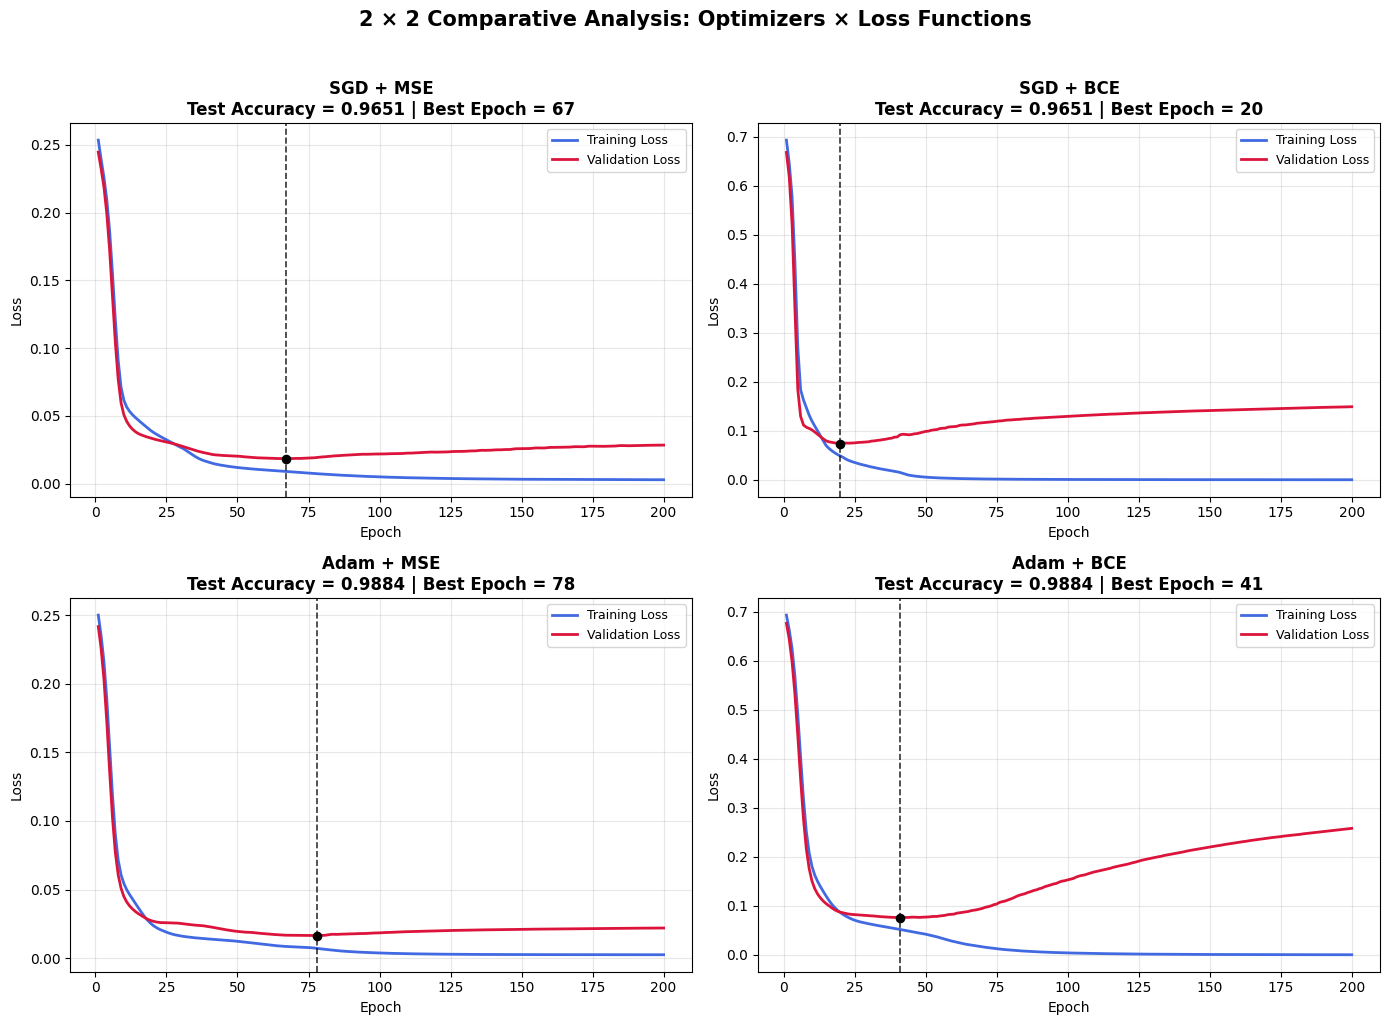


Files saved:
• 03_optimizer_loss_comparison_table.csv
• 03_optimizer_loss_comparison_curves.png

Important interpretation:
MSE and BCE loss values must not be compared directly because they are measured on different scales. Compare the configurations primarily using convergence epoch, validation accuracy, test accuracy, Recall/Sensitivity, F1-score, and AUC-ROC.


In [18]:
# ============================================================
# CELL 17: Comparative Table and 2 × 2 Loss-Curve Dashboard
# ============================================================

# ------------------------------------------------------------
# Create the required comparison table
# ------------------------------------------------------------
comparison_table = pd.DataFrame({
    "Configuration": list(comparison_results.keys()),
    "Epochs to Converge": [
        comparison_results[name]["epochs_to_converge"]
        for name in comparison_results
    ],
    "Final Training Loss": [
        comparison_results[name]["final_train_loss"]
        for name in comparison_results
    ],
    "Final Validation Loss": [
        comparison_results[name]["final_val_loss"]
        for name in comparison_results
    ],
    "Best Validation Accuracy": [
        comparison_results[name]["best_val_accuracy"]
        for name in comparison_results
    ],
    "Final Test Accuracy": [
        comparison_results[name]["final_test_accuracy"]
        for name in comparison_results
    ]
})

print("Required 2 × 2 Optimizer/Loss Comparison Table")
display(comparison_table.round(4))

# Save a copy for your submission/report
comparison_table.round(4).to_csv(
    "03_optimizer_loss_comparison_table.csv",
    index=False
)

# ------------------------------------------------------------
# Create 2 × 2 loss-curve dashboard
# ------------------------------------------------------------
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for ax, (config_name, result) in zip(axes, comparison_results.items()):

    history = result["history"]
    epochs = range(1, len(history["loss"]) + 1)

    # Training and validation loss curves
    ax.plot(
        epochs,
        history["loss"],
        label="Training Loss",
        color="royalblue",
        linewidth=2
    )

    ax.plot(
        epochs,
        history["val_loss"],
        label="Validation Loss",
        color="crimson",
        linewidth=2
    )

    # Mark best validation-loss epoch
    best_epoch = result["epochs_to_converge"]
    best_val_loss = result["best_val_loss"]

    ax.axvline(
        best_epoch,
        color="black",
        linestyle="--",
        linewidth=1.2,
        alpha=0.8
    )

    ax.scatter(
        best_epoch,
        best_val_loss,
        color="black",
        s=35,
        zorder=5
    )

    # Labels and title
    ax.set_title(
        f"{config_name}\n"
        f"Test Accuracy = {result['final_test_accuracy']:.4f} | "
        f"Best Epoch = {best_epoch}",
        fontweight="bold"
    )

    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

plt.suptitle(
    "2 × 2 Comparative Analysis: Optimizers × Loss Functions",
    fontsize=15,
    fontweight="bold",
    y=1.02
)

plt.tight_layout()
plt.savefig(
    "03_optimizer_loss_comparison_curves.png",
    dpi=200,
    bbox_inches="tight"
)
plt.show()

print("\nFiles saved:")
print("• 03_optimizer_loss_comparison_table.csv")
print("• 03_optimizer_loss_comparison_curves.png")

print("\nImportant interpretation:")
print(
    "MSE and BCE loss values must not be compared directly because "
    "they are measured on different scales. Compare the configurations "
    "primarily using convergence epoch, validation accuracy, test accuracy, "
    "Recall/Sensitivity, F1-score, and AUC-ROC."
)

In [19]:
# ============================================================
# CELL 18: Final Model Test Evaluation
# Selected model: Regularized Adam + BCE + Early Stopping
# ============================================================

# The model selected for final clinical evaluation.
# It already has its best validation-loss weights restored
# by the EarlyStopping callback.
final_model = reg_model
final_model_name = (
    "Regularized FFNN: Adam + Binary Cross-Entropy + "
    "BatchNorm + Dropout(0.2) + Early Stopping"
)

print("Final model selected for clinical test evaluation:")
print(final_model_name)
print(f"\nArchitecture: 20 → 10 → 10 → 10 → 10 → 10 → 1")
print(f"Selected using validation performance at epoch: {best_reg_epoch}")
print(f"Validation loss at selected epoch: {best_reg_val_loss:.4f}")
print(f"Validation accuracy at selected epoch: {best_reg_val_acc:.4f}")

# ------------------------------------------------------------
# Generate predicted probabilities for the held-out test set.
# Each value is P(Malignant = 1).
# ------------------------------------------------------------
test_probabilities = final_model.predict(
    X_test_scaled,
    verbose=0
).ravel()

# Default clinical classification threshold
classification_threshold = 0.50

# Convert probabilities into class labels:
# 0 = Benign, 1 = Malignant
test_predictions = (
    test_probabilities >= classification_threshold
).astype(int)

# Final test-set loss and accuracy
final_test_loss, final_test_accuracy = final_model.evaluate(
    X_test_scaled,
    y_test,
    verbose=0
)

print("\nHeld-Out Test Set Results")
print("-" * 45)
print(f"Number of test patients: {len(y_test)}")
print(f"Classification threshold: {classification_threshold:.2f}")
print(f"Test Binary Cross-Entropy Loss: {final_test_loss:.4f}")
print(f"Test Accuracy: {final_test_accuracy:.4f} ({final_test_accuracy * 100:.2f}%)")

print("\nFirst 10 test predictions:")
prediction_preview = pd.DataFrame({
    "Actual Class": y_test.to_numpy()[:10],
    "Predicted Probability (Malignant)": test_probabilities[:10],
    "Predicted Class": test_predictions[:10]
})

prediction_preview["Actual Diagnosis"] = prediction_preview["Actual Class"].map(
    {0: "Benign", 1: "Malignant"}
)

prediction_preview["Predicted Diagnosis"] = prediction_preview["Predicted Class"].map(
    {0: "Benign", 1: "Malignant"}
)

display(prediction_preview.round(4))

# Safety checks
assert len(test_probabilities) == len(y_test)
assert set(np.unique(test_predictions)).issubset({0, 1})

print("\n✓ Test probabilities and binary predictions generated successfully.")

Final model selected for clinical test evaluation:
Regularized FFNN: Adam + Binary Cross-Entropy + BatchNorm + Dropout(0.2) + Early Stopping

Architecture: 20 → 10 → 10 → 10 → 10 → 10 → 1
Selected using validation performance at epoch: 129
Validation loss at selected epoch: 0.1053
Validation accuracy at selected epoch: 0.9765

Held-Out Test Set Results
---------------------------------------------
Number of test patients: 86
Classification threshold: 0.50
Test Binary Cross-Entropy Loss: 0.0492
Test Accuracy: 1.0000 (100.00%)

First 10 test predictions:


,Actual Class,Predicted Probability (Malignant),Predicted Class,Actual Diagnosis,Predicted Diagnosis
0,1,0.9961,1,Malignant,Malignant
1,0,0.0110,0,Benign,Benign
2,0,0.0154,0,Benign,Benign
3,0,0.0124,0,Benign,Benign
4,0,0.0180,0,Benign,Benign
5,1,0.8782,1,Malignant,Malignant
6,0,0.0122,0,Benign,Benign
7,1,0.9977,1,Malignant,Malignant
8,0,0.0107,0,Benign,Benign
9,0,0.0133,0,Benign,Benign



✓ Test probabilities and binary predictions generated successfully.


Confusion Matrix Values (Held-Out Test Set)
-------------------------------------------------------
True Negatives  (TN): 54  → Benign correctly predicted as Benign
False Positives (FP): 0  → Benign incorrectly predicted as Malignant
False Negatives (FN): 0  → Malignant incorrectly predicted as Benign
True Positives  (TP): 32  → Malignant correctly predicted as Malignant

Clinical Performance Metrics
-------------------------------------------------------
Accuracy:                1.0000 (100.00%)
Precision:               1.0000 (100.00%)
Recall / Sensitivity:    1.0000 (100.00%)
Specificity:             1.0000 (100.00%)
F1-Score:                1.0000

Detailed Classification Report
-------------------------------------------------------
               precision    recall  f1-score   support

   Benign (0)     1.0000    1.0000    1.0000        54
Malignant (1)     1.0000    1.0000    1.0000        32

     accuracy                         1.0000        86
    macro avg     1.0000    1.

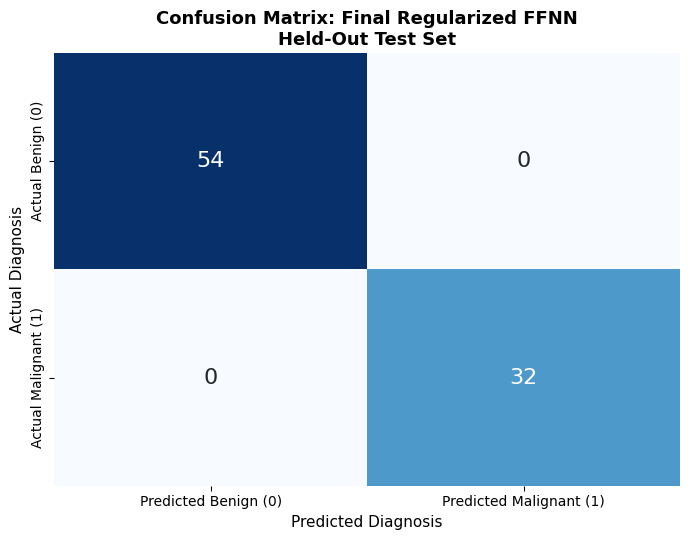


Clinical Interpretation
-------------------------------------------------------
• Sensitivity/Recall = 100.00%: the model detected 32 out of 32 malignant cases.
• Specificity = 100.00%: the model correctly identified 54 out of 54 benign cases.
• False Negatives = 0: these are missed cancer cases and are the most clinically dangerous error.
• False Positives = 0: these are benign cases incorrectly flagged as malignant, potentially causing additional tests or anxiety.

✓ Confusion matrix saved as: 04_confusion_matrix.png


In [20]:
# ============================================================
# CELL 19: Confusion Matrix and Clinical Performance Metrics
# ============================================================

# ------------------------------------------------------------
# Confusion matrix
#
# Matrix format:
#                Predicted Benign   Predicted Malignant
# Actual Benign         TN                  FP
# Actual Malignant      FN                  TP
# ------------------------------------------------------------
cm = confusion_matrix(y_test, test_predictions)

TN, FP, FN, TP = cm.ravel()

# ------------------------------------------------------------
# Clinical performance metrics
# ------------------------------------------------------------
accuracy = accuracy_score(y_test, test_predictions)

# Precision:
# Of all patients predicted as Malignant, how many were truly Malignant?
precision = precision_score(y_test, test_predictions, zero_division=0)

# Recall / Sensitivity:
# Of all truly Malignant patients, how many did the model detect?
recall = recall_score(y_test, test_predictions, zero_division=0)
sensitivity = recall

# Specificity:
# Of all truly Benign patients, how many did the model correctly identify?
specificity = TN / (TN + FP) if (TN + FP) != 0 else 0

# F1-score:
# Harmonic mean of Precision and Recall
f1 = f1_score(y_test, test_predictions, zero_division=0)

# ------------------------------------------------------------
# Print confusion-matrix counts
# ------------------------------------------------------------
print("Confusion Matrix Values (Held-Out Test Set)")
print("-" * 55)
print(f"True Negatives  (TN): {TN}  → Benign correctly predicted as Benign")
print(f"False Positives (FP): {FP}  → Benign incorrectly predicted as Malignant")
print(f"False Negatives (FN): {FN}  → Malignant incorrectly predicted as Benign")
print(f"True Positives  (TP): {TP}  → Malignant correctly predicted as Malignant")

print("\nClinical Performance Metrics")
print("-" * 55)
print(f"Accuracy:                {accuracy:.4f} ({accuracy * 100:.2f}%)")
print(f"Precision:               {precision:.4f} ({precision * 100:.2f}%)")
print(f"Recall / Sensitivity:    {sensitivity:.4f} ({sensitivity * 100:.2f}%)")
print(f"Specificity:             {specificity:.4f} ({specificity * 100:.2f}%)")
print(f"F1-Score:                {f1:.4f}")

# ------------------------------------------------------------
# Classification report
# ------------------------------------------------------------
print("\nDetailed Classification Report")
print("-" * 55)

print(
    classification_report(
        y_test,
        test_predictions,
        target_names=["Benign (0)", "Malignant (1)"],
        digits=4,
        zero_division=0
    )
)

# ------------------------------------------------------------
# Visual confusion matrix
# ------------------------------------------------------------
plt.figure(figsize=(7, 5.5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False,
    xticklabels=["Predicted Benign (0)", "Predicted Malignant (1)"],
    yticklabels=["Actual Benign (0)", "Actual Malignant (1)"],
    annot_kws={"size": 16}
)

plt.title(
    "Confusion Matrix: Final Regularized FFNN\nHeld-Out Test Set",
    fontsize=13,
    fontweight="bold"
)
plt.xlabel("Predicted Diagnosis", fontsize=11)
plt.ylabel("Actual Diagnosis", fontsize=11)
plt.tight_layout()

plt.savefig("04_confusion_matrix.png", dpi=300, bbox_inches="tight")
plt.show()

# ------------------------------------------------------------
# Clinical interpretation
# ------------------------------------------------------------
print("\nClinical Interpretation")
print("-" * 55)
print(
    f"• Sensitivity/Recall = {sensitivity:.2%}: "
    f"the model detected {TP} out of {TP + FN} malignant cases."
)

print(
    f"• Specificity = {specificity:.2%}: "
    f"the model correctly identified {TN} out of {TN + FP} benign cases."
)

print(
    f"• False Negatives = {FN}: these are missed cancer cases "
    f"and are the most clinically dangerous error."
)

print(
    f"• False Positives = {FP}: these are benign cases incorrectly flagged "
    f"as malignant, potentially causing additional tests or anxiety."
)

print("\n✓ Confusion matrix saved as: 04_confusion_matrix.png")

AUC-ROC Evaluation
---------------------------------------------
AUC-ROC Score: 1.0000


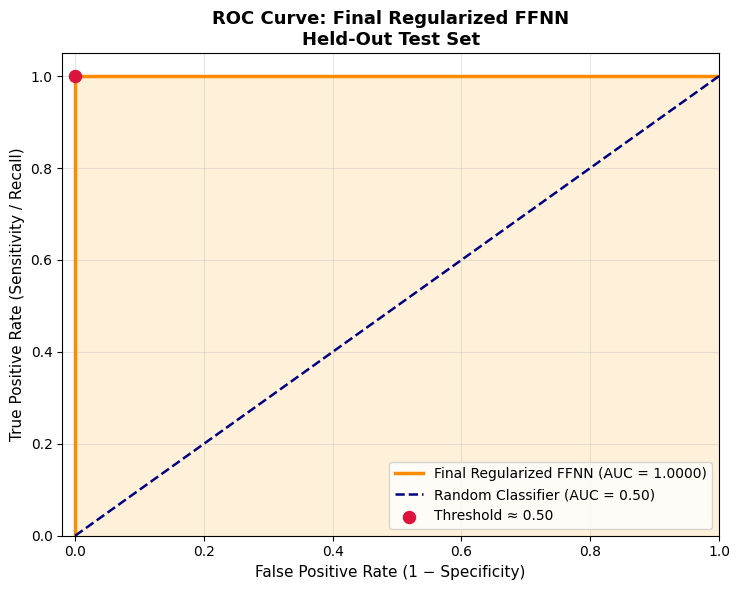


Interpretation
---------------------------------------------
AUC = 1.0000 indicates excellent discrimination between Benign and Malignant cases on this held-out test split.

Important clinical caution: an AUC of 1.00 on this particular 86-patient test split does not prove perfect real-world performance. The model would require external validation on independent patient populations before any clinical use.

✓ ROC curve saved as: 05_roc_auc_curve.png


In [26]:
# ============================================================
# CELL 20: ROC Curve and AUC-ROC Evaluation
# ============================================================

# ------------------------------------------------------------
# ROC curve:
# - Uses predicted probabilities, not only hard class labels.
# - Evaluates the trade-off between:
#     True Positive Rate = Sensitivity / Recall
#     False Positive Rate = 1 - Specificity
# - At many possible classification thresholds.
# ------------------------------------------------------------
fpr, tpr, thresholds = roc_curve(y_test, test_probabilities)

# Area Under the ROC Curve
roc_auc = auc(fpr, tpr)

print("AUC-ROC Evaluation")
print("-" * 45)
print(f"AUC-ROC Score: {roc_auc:.4f}")

# ------------------------------------------------------------
# Plot ROC curve
# ------------------------------------------------------------
plt.figure(figsize=(7.5, 6))

plt.plot(
    fpr,
    tpr,
    color="darkorange",
    linewidth=2.5,
    label=f"Final Regularized FFNN (AUC = {roc_auc:.4f})"
)

# Random-classifier reference line
plt.plot(
    [0, 1],
    [0, 1],
    color="navy",
    linestyle="--",
    linewidth=1.8,
    label="Random Classifier (AUC = 0.50)"
)

# Fill under ROC curve
plt.fill_between(
    fpr,
    tpr,
    color="orange",
    alpha=0.15
)

# Mark the default classification point: threshold = 0.50
default_index = np.argmin(np.abs(thresholds - 0.50))

plt.scatter(
    fpr[default_index],
    tpr[default_index],
    color="crimson",
    s=75,
    zorder=5,
    label=f"Threshold ≈ 0.50"
)

plt.title(
    "ROC Curve: Final Regularized FFNN\nHeld-Out Test Set",
    fontsize=13,
    fontweight="bold"
)
plt.xlabel("False Positive Rate (1 − Specificity)", fontsize=11)
plt.ylabel("True Positive Rate (Sensitivity / Recall)", fontsize=11)
plt.xlim([-0.02, 1.0])
plt.ylim([0.0, 1.05])
plt.grid(alpha=0.3)
plt.legend(loc="lower right")
plt.tight_layout()

plt.savefig("05_roc_auc_curve.png", dpi=300, bbox_inches="tight")
plt.show()

# ------------------------------------------------------------
# Interpretation
# ------------------------------------------------------------
print("\nInterpretation")
print("-" * 45)

if roc_auc >= 0.90:
    print(
        f"AUC = {roc_auc:.4f} indicates excellent discrimination between "
        "Benign and Malignant cases on this held-out test split."
    )
elif roc_auc >= 0.80:
    print(
        f"AUC = {roc_auc:.4f} indicates good discrimination between "
        "Benign and Malignant cases."
    )
else:
    print(
        f"AUC = {roc_auc:.4f} indicates limited discrimination ability."
    )

print(
    "\nImportant clinical caution: an AUC of 1.00 on this particular "
    "86-patient test split does not prove perfect real-world performance. "
    "The model would require external validation on independent patient "
    "populations before any clinical use."
)

print("\n✓ ROC curve saved as: 05_roc_auc_curve.png")

Predicted Probability Summary
-------------------------------------------------------

Actual Benign patients:
Number of cases: 54
Minimum predicted malignant probability: 0.0073
Maximum predicted malignant probability: 0.0851
Mean predicted malignant probability:    0.0164

Actual Malignant patients:
Number of cases: 32
Minimum predicted malignant probability: 0.5995
Maximum predicted malignant probability: 0.9984
Mean predicted malignant probability:    0.9088


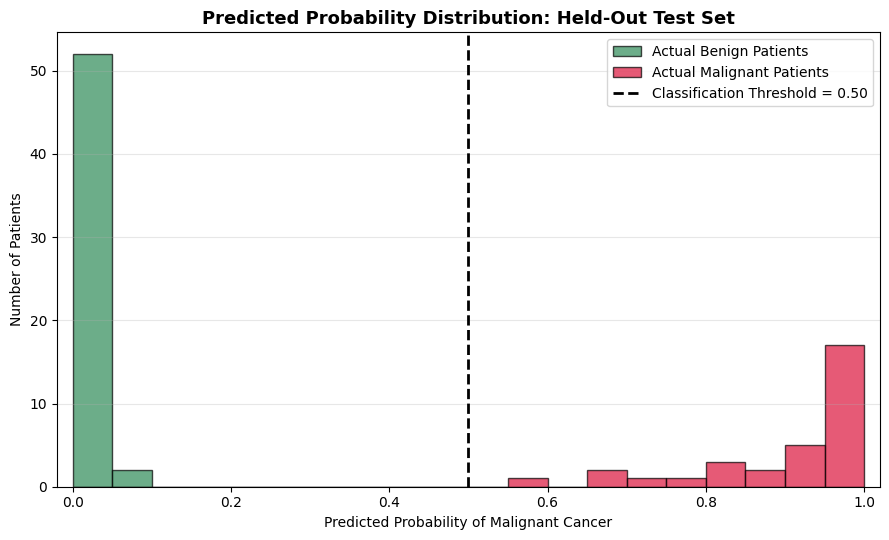


Interpretation:
A strong diagnostic model should assign low malignant probabilities to benign cases and high malignant probabilities to malignant cases. Clear separation around the 0.50 threshold supports the AUC-ROC result.

✓ Probability distribution plot saved as: 06_probability_distribution.png


In [23]:
# ============================================================
# CELL 21: Predicted Probability Distribution
# ============================================================

# Separate predicted malignant probabilities by actual diagnosis
benign_probabilities = test_probabilities[y_test.to_numpy() == 0]
malignant_probabilities = test_probabilities[y_test.to_numpy() == 1]

# Print probability ranges for clinical interpretation
print("Predicted Probability Summary")
print("-" * 55)

print("\nActual Benign patients:")
print(f"Number of cases: {len(benign_probabilities)}")
print(f"Minimum predicted malignant probability: {benign_probabilities.min():.4f}")
print(f"Maximum predicted malignant probability: {benign_probabilities.max():.4f}")
print(f"Mean predicted malignant probability:    {benign_probabilities.mean():.4f}")

print("\nActual Malignant patients:")
print(f"Number of cases: {len(malignant_probabilities)}")
print(f"Minimum predicted malignant probability: {malignant_probabilities.min():.4f}")
print(f"Maximum predicted malignant probability: {malignant_probabilities.max():.4f}")
print(f"Mean predicted malignant probability:    {malignant_probabilities.mean():.4f}")

# ------------------------------------------------------------
# Plot probability distributions
# ------------------------------------------------------------
plt.figure(figsize=(9, 5.5))

bins = np.linspace(0, 1, 21)

plt.hist(
    benign_probabilities,
    bins=bins,
    alpha=0.70,
    color="seagreen",
    edgecolor="black",
    label="Actual Benign Patients"
)

plt.hist(
    malignant_probabilities,
    bins=bins,
    alpha=0.70,
    color="crimson",
    edgecolor="black",
    label="Actual Malignant Patients"
)

# Classification threshold used by the model
plt.axvline(
    x=classification_threshold,
    color="black",
    linestyle="--",
    linewidth=2,
    label=f"Classification Threshold = {classification_threshold:.2f}"
)

plt.title(
    "Predicted Probability Distribution: Held-Out Test Set",
    fontsize=13,
    fontweight="bold"
)
plt.xlabel("Predicted Probability of Malignant Cancer")
plt.ylabel("Number of Patients")
plt.xlim(-0.02, 1.02)
plt.grid(axis="y", alpha=0.3)
plt.legend()
plt.tight_layout()

plt.savefig("06_probability_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

print("\nInterpretation:")
print(
    "A strong diagnostic model should assign low malignant probabilities "
    "to benign cases and high malignant probabilities to malignant cases. "
    "Clear separation around the 0.50 threshold supports the AUC-ROC result."
)

print("\n✓ Probability distribution plot saved as: 06_probability_distribution.png")

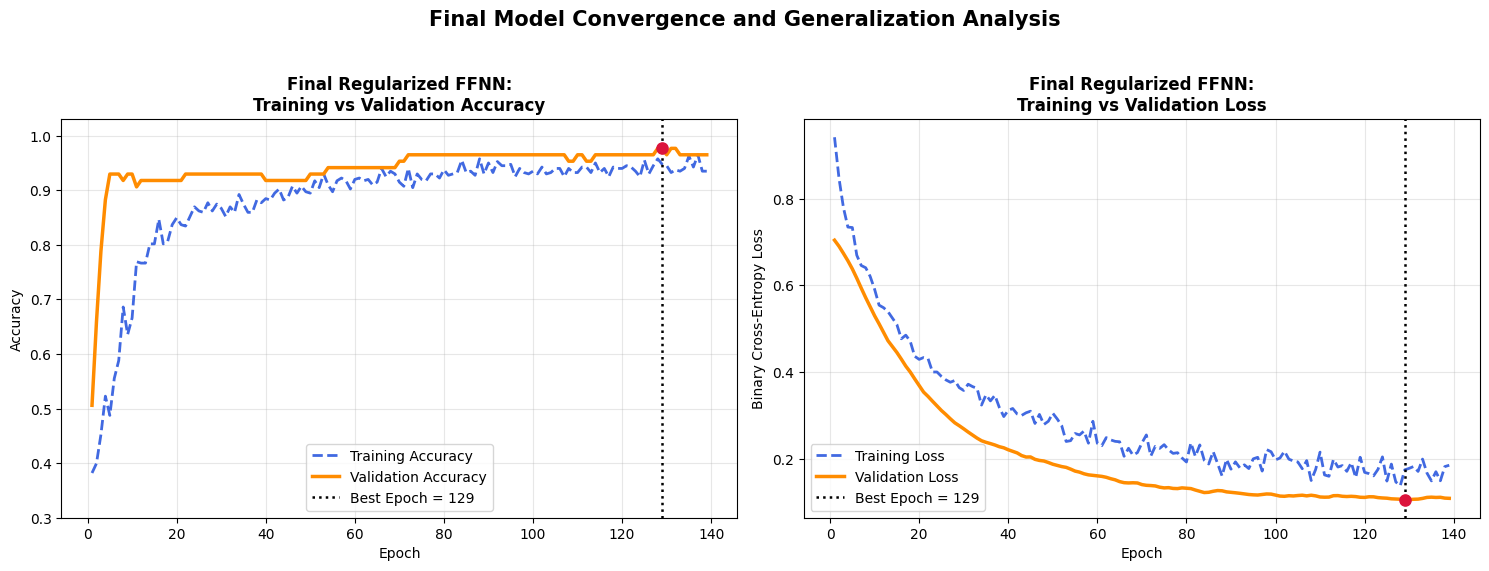

Final Restored-Model Evaluation
--------------------------------------------------
Training accuracy:   0.9849
Validation accuracy: 0.9765
Test accuracy:       1.0000

Training loss:       0.0779
Validation loss:     0.1053
Test loss:           0.0492

Interpretation:
The training and validation accuracy curves are relatively close, indicating controlled variance after regularization. Dropout is active during training, so the training accuracy recorded during fit can be lower than the final evaluation accuracy, where dropout is disabled.

✓ Accuracy/loss curves saved as:
  07_final_model_accuracy_loss_curves.png


In [27]:
# ============================================================
# CELL 21: Final Model Training/Validation Accuracy Analysis
# ============================================================

# Use the history from the final regularized model.
final_history = reg_history.history

final_epochs = np.arange(1, len(final_history["loss"]) + 1)

# ------------------------------------------------------------
# Accuracy and loss from the restored-model training history
# ------------------------------------------------------------
train_accuracy_history = final_history["accuracy"]
val_accuracy_history = final_history["val_accuracy"]

train_loss_history = final_history["loss"]
val_loss_history = final_history["val_loss"]

# ------------------------------------------------------------
# Plot accuracy and loss together
# ------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

# ===== Accuracy curve =====
axes[0].plot(
    final_epochs,
    train_accuracy_history,
    color="royalblue",
    linestyle="--",
    linewidth=2,
    label="Training Accuracy"
)

axes[0].plot(
    final_epochs,
    val_accuracy_history,
    color="darkorange",
    linewidth=2.5,
    label="Validation Accuracy"
)

axes[0].axvline(
    best_reg_epoch,
    color="black",
    linestyle=":",
    linewidth=1.8,
    label=f"Best Epoch = {best_reg_epoch}"
)

axes[0].scatter(
    best_reg_epoch,
    best_reg_val_acc,
    color="crimson",
    s=65,
    zorder=5
)

axes[0].set_title(
    "Final Regularized FFNN:\nTraining vs Validation Accuracy",
    fontweight="bold"
)
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].set_ylim(0.3, 1.03)
axes[0].legend()
axes[0].grid(alpha=0.3)

# ===== Loss curve =====
axes[1].plot(
    final_epochs,
    train_loss_history,
    color="royalblue",
    linestyle="--",
    linewidth=2,
    label="Training Loss"
)

axes[1].plot(
    final_epochs,
    val_loss_history,
    color="darkorange",
    linewidth=2.5,
    label="Validation Loss"
)

axes[1].axvline(
    best_reg_epoch,
    color="black",
    linestyle=":",
    linewidth=1.8,
    label=f"Best Epoch = {best_reg_epoch}"
)

axes[1].scatter(
    best_reg_epoch,
    best_reg_val_loss,
    color="crimson",
    s=65,
    zorder=5
)

axes[1].set_title(
    "Final Regularized FFNN:\nTraining vs Validation Loss",
    fontweight="bold"
)
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Binary Cross-Entropy Loss")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle(
    "Final Model Convergence and Generalization Analysis",
    fontsize=15,
    fontweight="bold",
    y=1.03
)

plt.tight_layout()
plt.savefig(
    "07_final_model_accuracy_loss_curves.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

# ------------------------------------------------------------
# Calculate final train/validation metrics using the restored
# model weights. Dropout is disabled during evaluate().
# ------------------------------------------------------------
restored_train_loss, restored_train_accuracy = final_model.evaluate(
    X_train_scaled,
    y_train,
    verbose=0
)

restored_val_loss, restored_val_accuracy = final_model.evaluate(
    X_val_scaled,
    y_val,
    verbose=0
)

print("Final Restored-Model Evaluation")
print("-" * 50)
print(f"Training accuracy:   {restored_train_accuracy:.4f}")
print(f"Validation accuracy: {restored_val_accuracy:.4f}")
print(f"Test accuracy:       {final_test_accuracy:.4f}")
print(f"\nTraining loss:       {restored_train_loss:.4f}")
print(f"Validation loss:     {restored_val_loss:.4f}")
print(f"Test loss:           {final_test_loss:.4f}")

print("\nInterpretation:")
print(
    "The training and validation accuracy curves are relatively close, "
    "indicating controlled variance after regularization. Dropout is active "
    "during training, so the training accuracy recorded during fit can be "
    "lower than the final evaluation accuracy, where dropout is disabled."
)

print("\n✓ Accuracy/loss curves saved as:")
print("  07_final_model_accuracy_loss_curves.png")

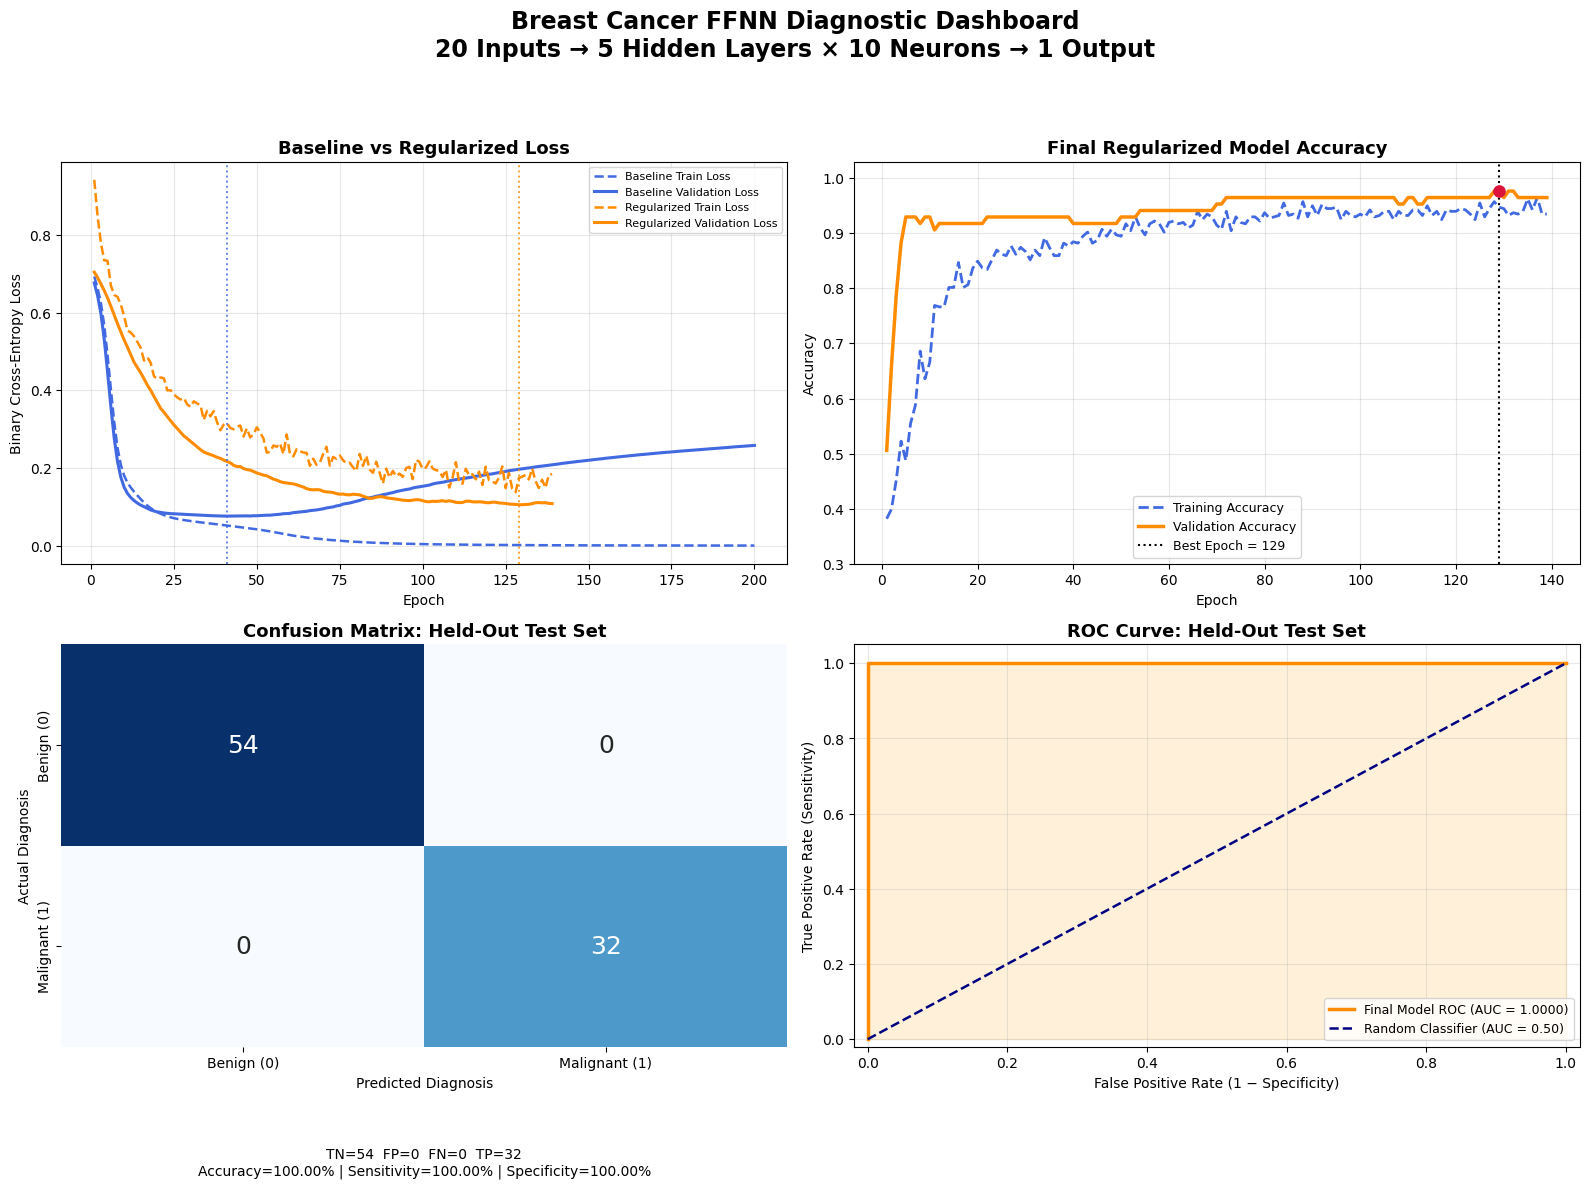

Final dashboard created successfully.
✓ Saved as: 08_final_composite_dashboard.png


In [28]:
# ============================================================
# CELL 22: Final Composite Visual Dashboard
# ============================================================

# Create epoch arrays
baseline_epochs = np.arange(
    1, len(baseline_history.history["loss"]) + 1
)

regularized_epochs = np.arange(
    1, len(reg_history.history["loss"]) + 1
)

# Create a 2 × 2 dashboard
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# ============================================================
# PANEL 1: Baseline vs Regularized Validation Loss
# ============================================================
ax = axes[0, 0]

# Baseline curves
ax.plot(
    baseline_epochs,
    baseline_history.history["loss"],
    color="royalblue",
    linestyle="--",
    linewidth=1.8,
    label="Baseline Train Loss"
)

ax.plot(
    baseline_epochs,
    baseline_history.history["val_loss"],
    color="royalblue",
    linewidth=2.2,
    label="Baseline Validation Loss"
)

# Regularized curves
ax.plot(
    regularized_epochs,
    reg_history.history["loss"],
    color="darkorange",
    linestyle="--",
    linewidth=1.8,
    label="Regularized Train Loss"
)

ax.plot(
    regularized_epochs,
    reg_history.history["val_loss"],
    color="darkorange",
    linewidth=2.2,
    label="Regularized Validation Loss"
)

# Mark best epochs
ax.axvline(
    best_baseline_epoch,
    color="royalblue",
    linestyle=":",
    linewidth=1.4,
    alpha=0.8
)

ax.axvline(
    best_reg_epoch,
    color="darkorange",
    linestyle=":",
    linewidth=1.4,
    alpha=0.8
)

ax.set_title(
    "Baseline vs Regularized Loss",
    fontsize=13,
    fontweight="bold"
)
ax.set_xlabel("Epoch")
ax.set_ylabel("Binary Cross-Entropy Loss")
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

# ============================================================
# PANEL 2: Final Training vs Validation Accuracy
# ============================================================
ax = axes[0, 1]

ax.plot(
    regularized_epochs,
    reg_history.history["accuracy"],
    color="royalblue",
    linestyle="--",
    linewidth=2,
    label="Training Accuracy"
)

ax.plot(
    regularized_epochs,
    reg_history.history["val_accuracy"],
    color="darkorange",
    linewidth=2.5,
    label="Validation Accuracy"
)

ax.axvline(
    best_reg_epoch,
    color="black",
    linestyle=":",
    linewidth=1.5,
    label=f"Best Epoch = {best_reg_epoch}"
)

ax.scatter(
    best_reg_epoch,
    best_reg_val_acc,
    color="crimson",
    s=65,
    zorder=5
)

ax.set_title(
    "Final Regularized Model Accuracy",
    fontsize=13,
    fontweight="bold"
)
ax.set_xlabel("Epoch")
ax.set_ylabel("Accuracy")
ax.set_ylim(0.3, 1.03)
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

# ============================================================
# PANEL 3: Confusion Matrix
# ============================================================
ax = axes[1, 0]

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False,
    ax=ax,
    annot_kws={"size": 18},
    xticklabels=["Benign (0)", "Malignant (1)"],
    yticklabels=["Benign (0)", "Malignant (1)"]
)

ax.set_title(
    "Confusion Matrix: Held-Out Test Set",
    fontsize=13,
    fontweight="bold"
)
ax.set_xlabel("Predicted Diagnosis")
ax.set_ylabel("Actual Diagnosis")

# Add metric summary below the plot
ax.text(
    0.5,
    -0.25,
    f"TN={TN}  FP={FP}  FN={FN}  TP={TP}\n"
    f"Accuracy={accuracy:.2%} | Sensitivity={sensitivity:.2%} | "
    f"Specificity={specificity:.2%}",
    transform=ax.transAxes,
    ha="center",
    va="top",
    fontsize=10
)

# ============================================================
# PANEL 4: ROC Curve
# ============================================================
ax = axes[1, 1]

ax.plot(
    fpr,
    tpr,
    color="darkorange",
    linewidth=2.5,
    label=f"Final Model ROC (AUC = {roc_auc:.4f})"
)

ax.plot(
    [0, 1],
    [0, 1],
    color="navy",
    linestyle="--",
    linewidth=1.8,
    label="Random Classifier (AUC = 0.50)"
)

ax.fill_between(
    fpr,
    tpr,
    color="orange",
    alpha=0.15
)

ax.set_title(
    "ROC Curve: Held-Out Test Set",
    fontsize=13,
    fontweight="bold"
)
ax.set_xlabel("False Positive Rate (1 − Specificity)")
ax.set_ylabel("True Positive Rate (Sensitivity)")
ax.set_xlim([-0.02, 1.02])
ax.set_ylim([-0.02, 1.05])
ax.legend(fontsize=9, loc="lower right")
ax.grid(alpha=0.3)

# ============================================================
# Overall dashboard title and save
# ============================================================
fig.suptitle(
    "Breast Cancer FFNN Diagnostic Dashboard\n"
    "20 Inputs → 5 Hidden Layers × 10 Neurons → 1 Output",
    fontsize=17,
    fontweight="bold",
    y=0.99
)

plt.tight_layout(rect=[0, 0, 1, 0.95])

plt.savefig(
    "08_final_composite_dashboard.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Final dashboard created successfully.")
print("✓ Saved as: 08_final_composite_dashboard.png")

In [30]:

# ============================================================
# CELL 23: Final Architecture, Parameters, and Results Summary
# ============================================================

# ------------------------------------------------------------
# Part A: Baseline mathematical mapping and parameter table
# ------------------------------------------------------------
# Mathematical convention:
# h = activation(Wx + b)
# Therefore, W is shown as (output_neurons, input_neurons).
#
# Keras stores Dense kernels transposed:
# Keras kernel shape = (input_neurons, output_neurons).

architecture_table = pd.DataFrame({
    "Transformation": [
        "Input → Hidden 1",
        "Hidden 1 → Hidden 2",
        "Hidden 2 → Hidden 3",
        "Hidden 3 → Hidden 4",
        "Hidden 4 → Hidden 5",
        "Hidden 5 → Output"
    ],
    "Mathematical Weight W Shape": [
        "(10, 20)",
        "(10, 10)",
        "(10, 10)",
        "(10, 10)",
        "(10, 10)",
        "(1, 10)"
    ],
    "Keras Dense Kernel Shape": [
        "(20, 10)",
        "(10, 10)",
        "(10, 10)",
        "(10, 10)",
        "(10, 10)",
        "(10, 1)"
    ],
    "Bias b Shape": [
        "(10,)",
        "(10,)",
        "(10,)",
        "(10,)",
        "(10,)",
        "(1,)"
    ],
    "Trainable Parameters": [
        210,
        110,
        110,
        110,
        110,
        11
    ],
    "Activation": [
        "ReLU",
        "ReLU",
        "ReLU",
        "ReLU",
        "ReLU",
        "Sigmoid"
    ]
})

print("=" * 100)
print("BASELINE FFNN ARCHITECTURE AND MATRIX DIMENSIONS")
print("=" * 100)
display(architecture_table)

print("Baseline architecture:")
print("Input(20) → Dense(10, ReLU) → Dense(10, ReLU) → "
      "Dense(10, ReLU) → Dense(10, ReLU) → Dense(10, ReLU) → "
      "Dense(1, Sigmoid)")

print("\nTotal baseline trainable parameters:",
      architecture_table["Trainable Parameters"].sum())

# Save architecture table
architecture_table.to_csv(
    "09_baseline_architecture_parameters.csv",
    index=False
)

# ------------------------------------------------------------
# Part B: Final model summary
# ------------------------------------------------------------
final_summary = pd.DataFrame({
    "Item": [
        "Dataset",
        "Number of source clinical features",
        "Number of model input features",
        "Selected hidden-layer structure",
        "Output layer",
        "Loss function",
        "Final optimizer",
        "Dropout probability",
        "Early stopping patience",
        "Best regularized epoch",
        "Total baseline parameters",
        "Total regularized parameters",
        "Trainable regularized parameters",
        "Non-trainable BatchNorm parameters",
        "Test patients"
    ],
    "Value": [
        "UCI Wisconsin Diagnostic Breast Cancer",
        30,
        20,
        "Five hidden layers × 10 neurons, ReLU",
        "One neuron, Sigmoid",
        "Binary Cross-Entropy",
        "Adam, learning rate = 0.001",
        0.2,
        10,
        best_reg_epoch,
        661,
        reg_model.count_params(),
        761,
        100,
        len(y_test)
    ]
})

print("\n" + "=" * 100)
print("FINAL MODEL CONFIGURATION")
print("=" * 100)
display(final_summary)

final_summary.to_csv(
    "10_final_model_configuration.csv",
    index=False
)

# ------------------------------------------------------------
# Part C: Final clinical test metrics
# ------------------------------------------------------------
clinical_results = pd.DataFrame({
    "Metric": [
        "True Negatives (TN)",
        "False Positives (FP)",
        "False Negatives (FN)",
        "True Positives (TP)",
        "Accuracy",
        "Precision",
        "Recall / Sensitivity",
        "Specificity",
        "F1-Score",
        "AUC-ROC",
        "Test Binary Cross-Entropy Loss"
    ],
    "Value": [
        TN,
        FP,
        FN,
        TP,
        accuracy,
        precision,
        sensitivity,
        specificity,
        f1,
        roc_auc,
        final_test_loss
    ]
})

print("\n" + "=" * 100)
print("FINAL CLINICAL TEST RESULTS")
print("=" * 100)
display(clinical_results.round(4))

clinical_results.to_csv(
    "11_final_clinical_metrics.csv",
    index=False
)

# ------------------------------------------------------------
# Part D: Selected 20 features
# ------------------------------------------------------------
selected_features_table = pd.DataFrame({
    "Input Neuron Number": np.arange(1, 21),
    "Selected Feature": selected_feature_names
})

print("\n" + "=" * 100)
print("THE 20 SELECTED INPUT FEATURES")
print("=" * 100)
display(selected_features_table)

selected_features_table.to_csv(
    "12_selected_20_features.csv",
    index=False
)

# ------------------------------------------------------------
# Part E: Final saved files
# ------------------------------------------------------------
print("\nReport files created:")
print("✓ 09_baseline_architecture_parameters.csv")
print("✓ 10_final_model_configuration.csv")
print("✓ 11_final_clinical_metrics.csv")
print("✓ 12_selected_20_features.csv")
print("✓ 08_final_composite_dashboard.png")


BASELINE FFNN ARCHITECTURE AND MATRIX DIMENSIONS


,Transformation,Mathematical Weight W Shape,Keras Dense Kernel Shape,Bias b Shape,Trainable Parameters,Activation
0,Input → Hidden 1,"(10, 20)","(20, 10)","(10,)",210,ReLU
1,Hidden 1 → Hidden 2,"(10, 10)","(10, 10)","(10,)",110,ReLU
2,Hidden 2 → Hidden 3,"(10, 10)","(10, 10)","(10,)",110,ReLU
3,Hidden 3 → Hidden 4,"(10, 10)","(10, 10)","(10,)",110,ReLU
4,Hidden 4 → Hidden 5,"(10, 10)","(10, 10)","(10,)",110,ReLU
5,Hidden 5 → Output,"(1, 10)","(10, 1)","(1,)",11,Sigmoid


Baseline architecture:
Input(20) → Dense(10, ReLU) → Dense(10, ReLU) → Dense(10, ReLU) → Dense(10, ReLU) → Dense(10, ReLU) → Dense(1, Sigmoid)

Total baseline trainable parameters: 661

FINAL MODEL CONFIGURATION


,Item,Value
0,Dataset,UCI Wisconsin Diagnostic Breast Cancer
1,Number of source clinical features,30
2,Number of model input features,20
3,Selected hidden-layer structure,"Five hidden layers × 10 neurons, ReLU"
4,Output layer,"One neuron, Sigmoid"
5,Loss function,Binary Cross-Entropy
6,Final optimizer,"Adam, learning rate = 0.001"
7,Dropout probability,0.2
8,Early stopping patience,10
9,Best regularized epoch,129



FINAL CLINICAL TEST RESULTS


,Metric,Value
0,True Negatives (TN),54.0000
1,False Positives (FP),0.0000
2,False Negatives (FN),0.0000
3,True Positives (TP),32.0000
4,Accuracy,1.0000
5,Precision,1.0000
6,Recall / Sensitivity,1.0000
7,Specificity,1.0000
8,F1-Score,1.0000
9,AUC-ROC,1.0000



THE 20 SELECTED INPUT FEATURES


,Input Neuron Number,Selected Feature
0,1,mean_radius
1,2,mean_texture
2,3,mean_perimeter
3,4,mean_area
4,5,mean_smoothness
5,6,mean_compactness
6,7,mean_concavity
7,8,mean_concave_points
8,9,radius_se
9,10,perimeter_se



Report files created:
✓ 09_baseline_architecture_parameters.csv
✓ 10_final_model_configuration.csv
✓ 11_final_clinical_metrics.csv
✓ 12_selected_20_features.csv
✓ 08_final_composite_dashboard.png


In [32]:
# ============================================================
# CELL 24: Generate the Complete Analytical Report
# ============================================================

# ------------------------------------------------------------
# IMPORTANT:
# Keras model.fit() returns a History object.
# The actual loss and accuracy dictionaries are stored in:
#     baseline_history.history
#     reg_history.history
# ------------------------------------------------------------
baseline_hist = baseline_history.history
reg_hist = reg_history.history

# Convert the comparison table into readable text
comparison_text = comparison_table.round(4).to_string(index=False)

# Convert the selected features into a numbered list
selected_features_text = "\n".join(
    [
        f"  {i + 1:02d}. {feature}"
        for i, feature in enumerate(selected_feature_names)
    ]
)

# ------------------------------------------------------------
# Build the full analytical report
# ------------------------------------------------------------
analytical_report = f"""
============================================================
BREAST CANCER CLASSIFICATION USING A FEEDFORWARD NEURAL NETWORK
============================================================

1. DATASET
------------------------------------------------------------
Dataset:
Wisconsin Diagnostic Breast Cancer (WDBC), UCI Machine Learning Repository

Number of patient records: {len(df)}
Original number of clinical features: {len(feature_names)}
Model input features: 20

Target classes:
  0 = Benign
  1 = Malignant

Class distribution:
  Benign:    {int((y == 0).sum())} patients
  Malignant: {int((y == 1).sum())} patients

The original WDBC dataset contains 30 numerical clinical features.
Because the assignment specifies an input layer of 20 neurons, exactly
20 features were selected using ANOVA F-scores.

Feature selection was fitted using the training data only. This prevents
information from the validation and test sets leaking into the model
development process.

Selected input features:
{selected_features_text}


2. DATA PREPROCESSING
------------------------------------------------------------
The data was divided using stratified sampling so that the class
proportions were preserved in the three subsets.

  Training set:    {len(y_train)} patients
  Validation set:  {len(y_val)} patients
  Test set:        {len(y_test)} patients

The selected 20 features were standardized using StandardScaler.

The scaler was fitted only on the training data. The same training-set
mean and standard deviation were then used to transform the validation
and test sets. This prevents data leakage.


3. BASELINE FFNN ARCHITECTURE
------------------------------------------------------------
The required baseline architecture was:

  Input Layer:    20 neurons
  Hidden Layer 1: 10 neurons, ReLU
  Hidden Layer 2: 10 neurons, ReLU
  Hidden Layer 3: 10 neurons, ReLU
  Hidden Layer 4: 10 neurons, ReLU
  Hidden Layer 5: 10 neurons, ReLU
  Output Layer:   1 neuron, Sigmoid

Architecture mapping:

  20 → 10 → 10 → 10 → 10 → 10 → 1


Matrix dimensions using:

  h = activation(Wx + b)

The mathematical weight matrices and biases are:

  W1: (10, 20), b1: (10,)
  W2: (10, 10), b2: (10,)
  W3: (10, 10), b3: (10,)
  W4: (10, 10), b4: (10,)
  W5: (10, 10), b5: (10,)
  W6: (1, 10),  b6: (1,)


Trainable parameter calculation:

  Input → Hidden 1:
      (20 × 10) + 10 = 210 parameters

  Hidden 1 → Hidden 2:
      (10 × 10) + 10 = 110 parameters

  Hidden 2 → Hidden 3:
      (10 × 10) + 10 = 110 parameters

  Hidden 3 → Hidden 4:
      (10 × 10) + 10 = 110 parameters

  Hidden 4 → Hidden 5:
      (10 × 10) + 10 = 110 parameters

  Hidden 5 → Output:
      (10 × 1) + 1 = 11 parameters


  Total baseline trainable parameters = 661


4. LOSS FUNCTION
------------------------------------------------------------
Binary Cross-Entropy was selected as the primary loss function.

Formula:

  BCE = -[y log(p) + (1-y) log(1-p)]

where:

  y = true class label
  p = predicted probability of Malignant

Binary Cross-Entropy is appropriate because:

  1. The task is binary classification.
  2. The output layer contains one Sigmoid neuron.
  3. The Sigmoid output represents P(Malignant).
  4. BCE penalizes confident incorrect predictions strongly.
  5. BCE is designed for probabilistic binary classification.

Mean Squared Error was also evaluated in the comparative experiment,
but Binary Cross-Entropy is the theoretically preferred loss function
for a binary classifier with a Sigmoid output.


5. BASELINE MODEL RESULTS AND OVERFITTING
------------------------------------------------------------
The baseline model was trained for 200 epochs without regularization
or early stopping so that overfitting could be observed.

Best baseline validation-loss epoch:
  Epoch: {best_baseline_epoch}
  Validation loss: {best_baseline_val_loss:.4f}
  Validation accuracy: {best_baseline_val_acc:.4f}

At the end of baseline training:

  Training loss:       {baseline_hist["loss"][-1]:.4f}
  Validation loss:     {baseline_hist["val_loss"][-1]:.4f}
  Training accuracy:   {baseline_hist["accuracy"][-1]:.4f}
  Validation accuracy: {baseline_hist["val_accuracy"][-1]:.4f}

The baseline model showed overfitting because its training loss
continued to decrease while its validation loss increased after the
best validation-loss epoch. Its training accuracy eventually approached
100%, while the validation accuracy remained lower.

This motivated the use of Batch Normalization, Dropout, and Early
Stopping.


6. REGULARIZATION
------------------------------------------------------------
The regularized model used the same main Dense-layer architecture but
added the following components after each hidden linear layer:

  Dense → Batch Normalization → ReLU → Dropout

Regularization configuration:

  Batch Normalization: after each hidden Dense layer
  Dropout probability: 0.2
  Optimizer: Adam
  Learning rate: 0.001
  Early stopping patience: 10 epochs
  Restore best weights: True

Parameter count of the regularized model:

  Baseline Dense parameters:        661
  BatchNorm layers:                 5 × 40 = 200
  Total regularized parameters:     861
  Trainable regularized parameters: 761
  Non-trainable BatchNorm parameters: 100

The regularized model completed:

  {reg_epochs_completed} training epochs

Early stopping restored the weights from:

  Best epoch: {best_reg_epoch}
  Best validation loss: {best_reg_val_loss:.4f}
  Validation accuracy at best epoch: {best_reg_val_acc:.4f}

Evaluation after restoring the best weights:

  Training loss:       {reg_train_loss_restored:.4f}
  Training accuracy:   {reg_train_acc_restored:.4f}
  Validation loss:     {reg_val_loss_restored:.4f}
  Validation accuracy: {reg_val_acc_restored:.4f}

Dropout makes the training problem more difficult because 20% of the
hidden activations are randomly disabled during training. During
evaluation, Dropout is disabled, so the evaluation accuracy may be
higher than the accuracy recorded during training.


7. OPTIMIZER AND LOSS-FUNCTION COMPARISON
------------------------------------------------------------
The following four configurations were compared using the same
20-input baseline architecture:

  1. SGD with momentum + MSE
  2. SGD with momentum + Binary Cross-Entropy
  3. Adam + MSE
  4. Adam + Binary Cross-Entropy

{comparison_text}

Interpretation:

MSE and Binary Cross-Entropy losses are not directly comparable because
they have different scales and mathematical meanings.

The configurations should therefore be compared using:

  - Epochs to convergence
  - Validation accuracy
  - Test accuracy
  - Precision
  - Recall/Sensitivity
  - Specificity
  - F1-score
  - AUC-ROC

Binary Cross-Entropy remains the preferred loss function conceptually
because it is specifically designed for binary probabilistic
classification.

Adam generally provides adaptive learning rates and often converges
faster than standard SGD. The exact result depends on the random split,
initial weights, learning rate, and number of epochs.


8. FINAL MODEL
------------------------------------------------------------
The final model used for clinical evaluation was:

  Regularized FFNN
  Adam optimizer
  Binary Cross-Entropy loss
  Batch Normalization
  Dropout probability = 0.2
  Early Stopping with patience = 10
  Best validation-loss weights restored

Final architecture:

  20 → 10 → 10 → 10 → 10 → 10 → 1

The held-out test set was used only for final evaluation.


9. FINAL TEST-SET PERFORMANCE
------------------------------------------------------------
Held-out test set size: {len(y_test)} patients

Test Binary Cross-Entropy loss:
  {final_test_loss:.4f}

Test accuracy:
  {accuracy:.4f} ({accuracy * 100:.2f}%)


Confusion matrix values:

  True Negatives  (TN): {TN}
  False Positives (FP): {FP}
  False Negatives (FN): {FN}
  True Positives  (TP): {TP}


Clinical metrics:

  Precision:          {precision:.4f} ({precision * 100:.2f}%)
  Recall/Sensitivity: {sensitivity:.4f} ({sensitivity * 100:.2f}%)
  Specificity:        {specificity:.4f} ({specificity * 100:.2f}%)
  F1-Score:           {f1:.4f}
  AUC-ROC:            {roc_auc:.4f}


10. CLINICAL INTERPRETATION
------------------------------------------------------------
Sensitivity, also called Recall, measures the proportion of actual
Malignant patients detected by the model.

This is particularly important in cancer diagnosis because a False
Negative represents a malignant patient incorrectly classified as
Benign. Missing a cancer diagnosis is generally more serious than
sending a benign patient for additional testing.

Specificity measures the proportion of actual Benign patients correctly
identified by the model.

A low Specificity can produce more False Positives. These may result in
additional investigations, unnecessary procedures, cost, or patient
anxiety.

For this test split:

  Malignant cases detected:
      {TP} out of {TP + FN}

  Benign cases correctly identified:
      {TN} out of {TN + FP}

  Missed malignant cases:
      {FN}

  Benign cases incorrectly flagged:
      {FP}


11. WHY AUC-ROC IS IMPORTANT
------------------------------------------------------------
Accuracy evaluates model performance at only one classification
threshold, usually 0.50.

AUC-ROC evaluates the ability of the model to distinguish between
Benign and Malignant cases across many possible probability thresholds.

A high AUC-ROC is useful for a clinical diagnostic tool because:

  1. It evaluates discrimination across multiple thresholds.
  2. It shows the trade-off between Sensitivity and Specificity.
  3. It is more informative than accuracy when class distributions
     are not perfectly balanced.
  4. It allows the operating threshold to be adjusted for clinical use.
  5. It helps prioritize high Sensitivity when missed cancers are
     considered especially dangerous.

The model achieved:

  AUC-ROC = {roc_auc:.4f}

on this particular held-out test split.

The predicted probabilities showed clear class separation, with low
malignant probabilities for Benign patients and high malignant
probabilities for Malignant patients.


12. LIMITATIONS
------------------------------------------------------------
The WDBC dataset is relatively small, containing only 569 patients.

The held-out test set contains only {len(y_test)} patients. Therefore,
the perfect or near-perfect metrics obtained on this particular split
should not be interpreted as proof of perfect real-world clinical
performance.

The model would require additional testing, including:

  1. Repeated stratified cross-validation.
  2. Confidence intervals for the performance metrics.
  3. External validation using an independent patient population.
  4. Probability calibration analysis.
  5. Clinical threshold selection based on the costs of False
     Positives and False Negatives.
  6. Evaluation on data collected using different equipment,
     hospitals, and patient populations.

This is an educational machine-learning model and must not be used as
a standalone clinical diagnostic system.


13. CONCLUSION
------------------------------------------------------------
A feedforward neural network was successfully developed for Benign
versus Malignant breast-cancer classification.

The model strictly followed the required architecture:

  Input layer:    20 neurons
  Hidden layers:  5 layers × 10 ReLU neurons
  Output layer:   1 Sigmoid neuron

The baseline network contained 661 trainable parameters.

Batch Normalization, Dropout, and Early Stopping were successfully
implemented to improve training stability and control overfitting.

Binary Cross-Entropy was selected as the primary loss function because
it is appropriate for binary classification with a Sigmoid output.

The final model obtained strong performance on the held-out test split.
However, independent external validation is necessary before the model
could be considered for any real-world clinical application.
"""

# ------------------------------------------------------------
# Save the analytical report in TXT and Markdown formats
# ------------------------------------------------------------
with open("13_analytical_report.txt", "w", encoding="utf-8") as file:
    file.write(analytical_report)

with open("13_analytical_report.md", "w", encoding="utf-8") as file:
    file.write(analytical_report)

# Display the report in the notebook
print(analytical_report)

print("\n" + "=" * 75)
print("ANALYTICAL REPORT SAVED SUCCESSFULLY")
print("=" * 75)
print("✓ 13_analytical_report.txt")
print("✓ 13_analytical_report.md")


BREAST CANCER CLASSIFICATION USING A FEEDFORWARD NEURAL NETWORK

1. DATASET
------------------------------------------------------------
Dataset:
Wisconsin Diagnostic Breast Cancer (WDBC), UCI Machine Learning Repository

Number of patient records: 569
Original number of clinical features: 30
Model input features: 20

Target classes:
  0 = Benign
  1 = Malignant

Class distribution:
  Benign:    357 patients
  Malignant: 212 patients

The original WDBC dataset contains 30 numerical clinical features.
Because the assignment specifies an input layer of 20 neurons, exactly
20 features were selected using ANOVA F-scores.

Feature selection was fitted using the training data only. This prevents
information from the validation and test sets leaking into the model
development process.

Selected input features:
  01. mean_radius
  02. mean_texture
  03. mean_perimeter
  04. mean_area
  05. mean_smoothness
  06. mean_compactness
  07. mean_concavity
  08. mean_concave_points
  09. radius_se
  

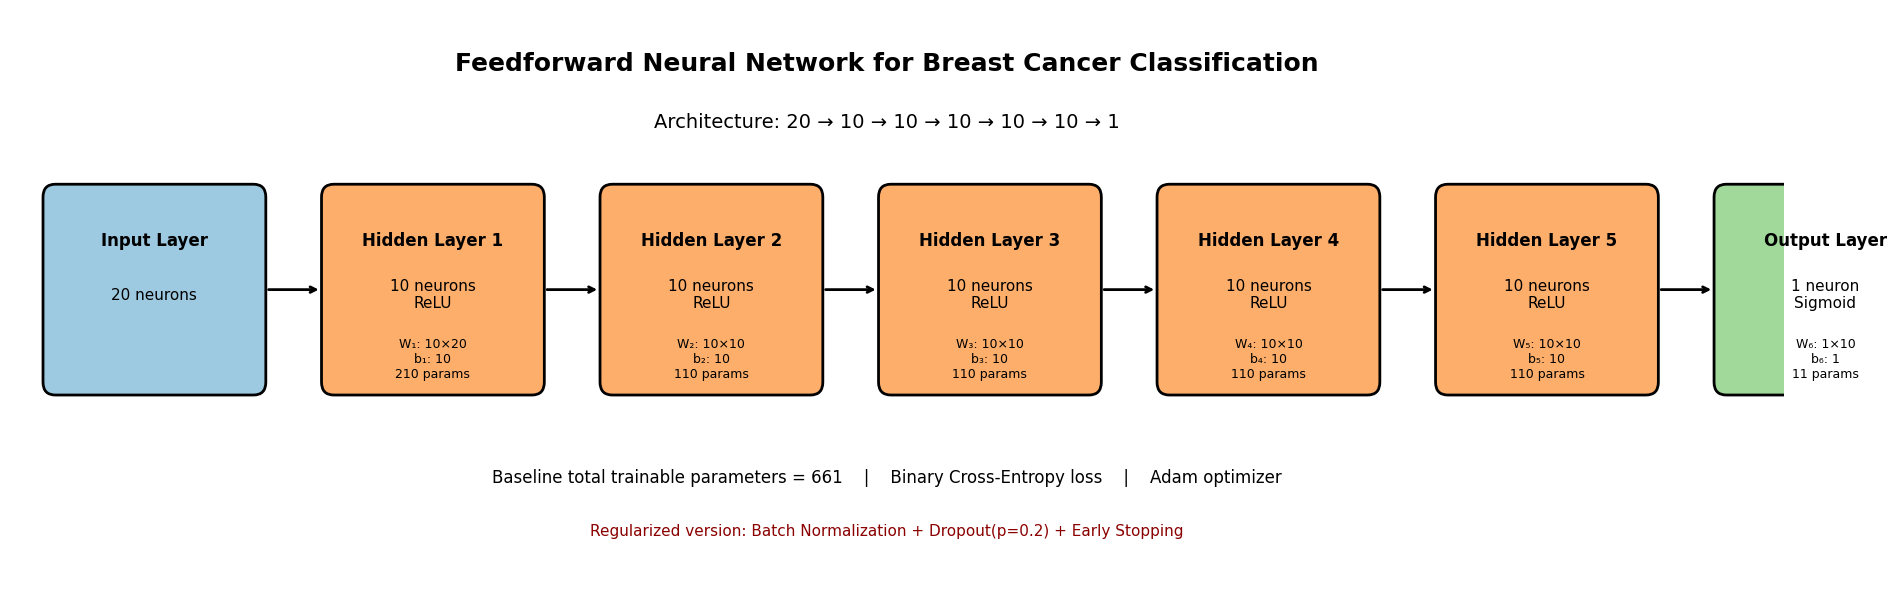

Architecture diagram created successfully.
✓ Saved as: 14_architecture_diagram.png


In [33]:
# ============================================================
# CELL 25: Create the FFNN Architecture Diagram
# ============================================================

import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch

# Architecture information
layer_names = [
    "Input Layer",
    "Hidden Layer 1",
    "Hidden Layer 2",
    "Hidden Layer 3",
    "Hidden Layer 4",
    "Hidden Layer 5",
    "Output Layer"
]

layer_sizes = [
    "20 neurons",
    "10 neurons\nReLU",
    "10 neurons\nReLU",
    "10 neurons\nReLU",
    "10 neurons\nReLU",
    "10 neurons\nReLU",
    "1 neuron\nSigmoid"
]

parameter_text = [
    "",
    "W₁: 10×20\nb₁: 10\n210 params",
    "W₂: 10×10\nb₂: 10\n110 params",
    "W₃: 10×10\nb₃: 10\n110 params",
    "W₄: 10×10\nb₄: 10\n110 params",
    "W₅: 10×10\nb₅: 10\n110 params",
    "W₆: 1×10\nb₆: 1\n11 params"
]

colors = [
    "#9ecae1",  # input
    "#fdae6b",  # hidden
    "#fdae6b",
    "#fdae6b",
    "#fdae6b",
    "#fdae6b",
    "#a1d99b"   # output
]

fig, ax = plt.subplots(figsize=(19, 6))

# Draw layer boxes
for i in range(len(layer_names)):
    x_position = i * 2.7

    box = FancyBboxPatch(
        (x_position, 2.0),
        2.0,
        1.8,
        boxstyle="round,pad=0.08,rounding_size=0.12",
        linewidth=2,
        edgecolor="black",
        facecolor=colors[i]
    )

    ax.add_patch(box)

    ax.text(
        x_position + 1.0,
        3.35,
        layer_names[i],
        ha="center",
        va="center",
        fontsize=12,
        fontweight="bold"
    )

    ax.text(
        x_position + 1.0,
        2.85,
        layer_sizes[i],
        ha="center",
        va="center",
        fontsize=11
    )

    if parameter_text[i]:
        ax.text(
            x_position + 1.0,
            2.25,
            parameter_text[i],
            ha="center",
            va="center",
            fontsize=9
        )

# Draw arrows between layers
for i in range(len(layer_names) - 1):
    start_x = i * 2.7 + 2.0
    end_x = (i + 1) * 2.7

    ax.annotate(
        "",
        xy=(end_x - 0.08, 2.9),
        xytext=(start_x + 0.08, 2.9),
        arrowprops=dict(
            arrowstyle="->",
            linewidth=2,
            color="black"
        )
    )

# Title and explanatory text
ax.text(
    8.1,
    5.0,
    "Feedforward Neural Network for Breast Cancer Classification",
    ha="center",
    va="center",
    fontsize=18,
    fontweight="bold"
)

ax.text(
    8.1,
    4.45,
    "Architecture: 20 → 10 → 10 → 10 → 10 → 10 → 1",
    ha="center",
    va="center",
    fontsize=14
)

ax.text(
    8.1,
    1.15,
    "Baseline total trainable parameters = 661    |    "
    "Binary Cross-Entropy loss    |    Adam optimizer",
    ha="center",
    va="center",
    fontsize=12
)

ax.text(
    8.1,
    0.65,
    "Regularized version: Batch Normalization + Dropout(p=0.2) "
    "+ Early Stopping",
    ha="center",
    va="center",
    fontsize=11,
    color="darkred"
)

# Format figure
ax.set_xlim(-0.4, 16.8)
ax.set_ylim(0.2, 5.5)
ax.axis("off")

plt.tight_layout()
plt.savefig(
    "14_architecture_diagram.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

print("Architecture diagram created successfully.")
print("✓ Saved as: 14_architecture_diagram.png")